# DỰ ĐOÁN BỆNH TIỂU ĐƯỜNG (DIABETES PREDICTION)

**Assignment 02 – Intelligent System Development**

---

## 1. Định nghĩa bài toán (Problem Definition)

### Mục tiêu
Xây dựng hệ thống học máy **dự đoán nguy cơ mắc bệnh tiểu đường** dựa trên các chỉ số lâm sàng và nhân khẩu học.

### Phân loại bài toán
- **Binary Classification (Phân loại nhị phân)**: 
  - Class 0: Không mắc tiểu đường (`Negative`)
  - Class 1: Mắc tiểu đường (`Positive`)

### Danh sách thuộc tính đầu vào ($X$)
| Feature | Kiểu dữ liệu | Ý nghĩa lâm sàng |
|---|---|---|
| `gender` | Categorical | Giới tính |
| `age` | Numerical (Continuous) | Độ tuổi |
| `hypertension` | Binary (0/1) | Tiền sử tăng huyết áp |
| `heart_disease` | Binary (0/1) | Tiền sử bệnh tim |
| `smoking_history` | Categorical | Tiền sử hút thuốc lá |
| `bmi` | Numerical (Continuous) | Chỉ số khối cơ thể (Body Mass Index) |
| `HbA1c_level` | Numerical (Continuous) | Chỉ số đường huyết gắn Hemoglobin (%) |
| `blood_glucose_level` | Numerical (Continuous) | Nồng độ đường huyết (mg/dL) |

**Biến mục tiêu ($y$)**: `diabetes` $\in \{0, 1\}$

## 2. Nguồn dữ liệu (Dataset Source)

- **Dataset**: Diabetes Prediction Dataset (Kaggle)
- **Tác giả**: Mohammed Mustafa
- **Quy mô**: ~100,000 bản ghi bệnh nhân thực tế
- **Đặc trưng**: 8 biến đầu vào ($X$) và 1 biến nhãn ($y$)

## 3. Tải dữ liệu (Dataset Loading)

In [1]:
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
%matplotlib inline
import matplotlib
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
import joblib, os, time, math

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.dummy import DummyClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import LinearSVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.calibration import CalibratedClassifierCV
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score, roc_auc_score, confusion_matrix,
    classification_report, ConfusionMatrixDisplay, roc_curve
)

RANDOM_STATE = 42
DATA_PATH = '../data/diabetes_prediction_dataset.csv'
MODEL_DIR = '../models'
os.makedirs(MODEL_DIR, exist_ok=True)

sns.set_theme(style='whitegrid', palette='Set2')
plt.rcParams.update({
    'figure.figsize': (10, 6),
    'font.size': 11,
    'axes.titlesize': 12,
    'axes.titleweight': 'bold'
})

df_raw = pd.read_csv(DATA_PATH)
print(f"Dataset loaded: {df_raw.shape[0]:,} rows, {df_raw.shape[1]} cols")
df_raw.head()

Dataset loaded: 100,000 rows, 9 cols


,gender,age,hypertension,heart_disease,smoking_history,bmi,HbA1c_level,blood_glucose_level,diabetes
0,Female,80.0,0,1,never,25.19,6.6,140,0
1,Female,54.0,0,0,No Info,27.32,6.6,80,0
2,Male,28.0,0,0,never,27.32,5.7,158,0
3,Female,36.0,0,0,current,23.45,5.0,155,0
4,Male,76.0,1,1,current,20.14,4.8,155,0


## 4. Khảo sát dữ liệu (Dataset Inspection)

In [2]:
print("Thông tin cấu trúc tập dữ liệu:")
df_raw.info()

Thông tin cấu trúc tập dữ liệu:
<class 'pandas.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 9 columns):
 #   Column               Non-Null Count   Dtype  
---  ------               --------------   -----  
 0   gender               100000 non-null  str    
 1   age                  100000 non-null  float64
 2   hypertension         100000 non-null  int64  
 3   heart_disease        100000 non-null  int64  
 4   smoking_history      100000 non-null  str    
 5   bmi                  100000 non-null  float64
 6   HbA1c_level          100000 non-null  float64
 7   blood_glucose_level  100000 non-null  int64  
 8   diabetes             100000 non-null  int64  
dtypes: float64(3), int64(4), str(2)
memory usage: 6.9 MB


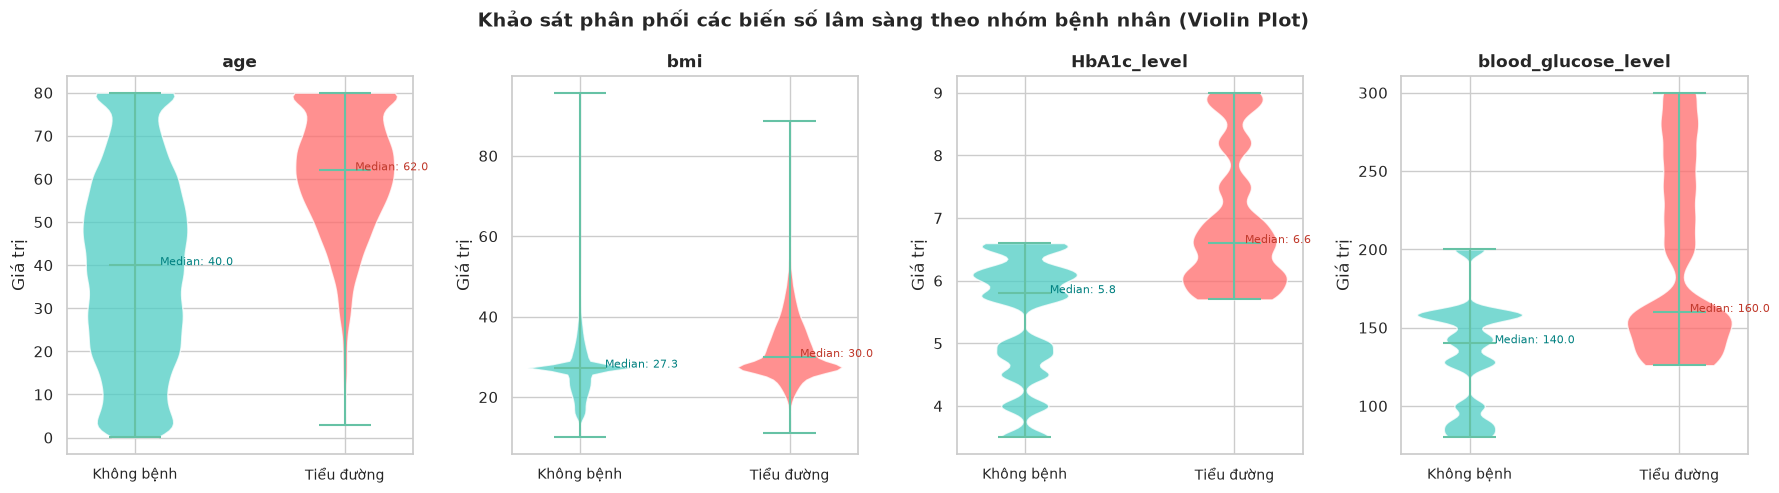

,gender,age,hypertension,heart_disease,smoking_history,bmi,HbA1c_level,blood_glucose_level,diabetes
count,100000,100000.00,100000.00,100000.00,100000,100000.00,100000.00,100000.00,100000.00
unique,3,NaN,NaN,NaN,6,NaN,NaN,NaN,NaN
top,Female,NaN,NaN,NaN,No Info,NaN,NaN,NaN,NaN
freq,58552,NaN,NaN,NaN,35816,NaN,NaN,NaN,NaN
mean,NaN,41.89,0.07,0.04,NaN,27.32,5.53,138.06,0.08
std,NaN,22.52,0.26,0.19,NaN,6.64,1.07,40.71,0.28
min,NaN,0.08,0.00,0.00,NaN,10.01,3.50,80.00,0.00
25%,NaN,24.00,0.00,0.00,NaN,23.63,4.80,100.00,0.00
50%,NaN,43.00,0.00,0.00,NaN,27.32,5.80,140.00,0.00
75%,NaN,60.00,0.00,0.00,NaN,29.58,6.20,159.00,0.00


In [3]:
numerical_features = ['age', 'bmi', 'HbA1c_level', 'blood_glucose_level']

fig, axes = plt.subplots(1, 4, figsize=(18, 5))
for i, col in enumerate(numerical_features):
    data_no = df_raw[df_raw['diabetes'] == 0][col].dropna()
    data_yes = df_raw[df_raw['diabetes'] == 1][col].dropna()
    vp = axes[i].violinplot([data_no, data_yes], positions=[0, 1], showmedians=True, showextrema=True)
    for j, pc in enumerate(vp['bodies']):
        pc.set_facecolor(['#4ECDC4', '#FF6B6B'][j])
        pc.set_alpha(0.75)
    axes[i].set_xticks([0, 1])
    axes[i].set_xticklabels(['Không bệnh', 'Tiểu đường'], fontsize=10)
    axes[i].set_title(col, fontsize=12)
    axes[i].set_ylabel('Giá trị')
    med0, med1 = data_no.median(), data_yes.median()
    axes[i].annotate(f'Median: {med0:.1f}', xy=(0, med0), xytext=(0.12, med0), fontsize=8, color='#008080')
    axes[i].annotate(f'Median: {med1:.1f}', xy=(1, med1), xytext=(1.05, med1), fontsize=8, color='#C0392B')

plt.suptitle('Khảo sát phân phối các biến số lâm sàng theo nhóm bệnh nhân (Violin Plot)', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig(os.path.join(MODEL_DIR, 'fig_violin_inspect.png'), dpi=100, bbox_inches='tight')
plt.show()

df_raw.describe(include='all').round(2)

## 5. Phân tích chất lượng dữ liệu (Data Quality Analysis)

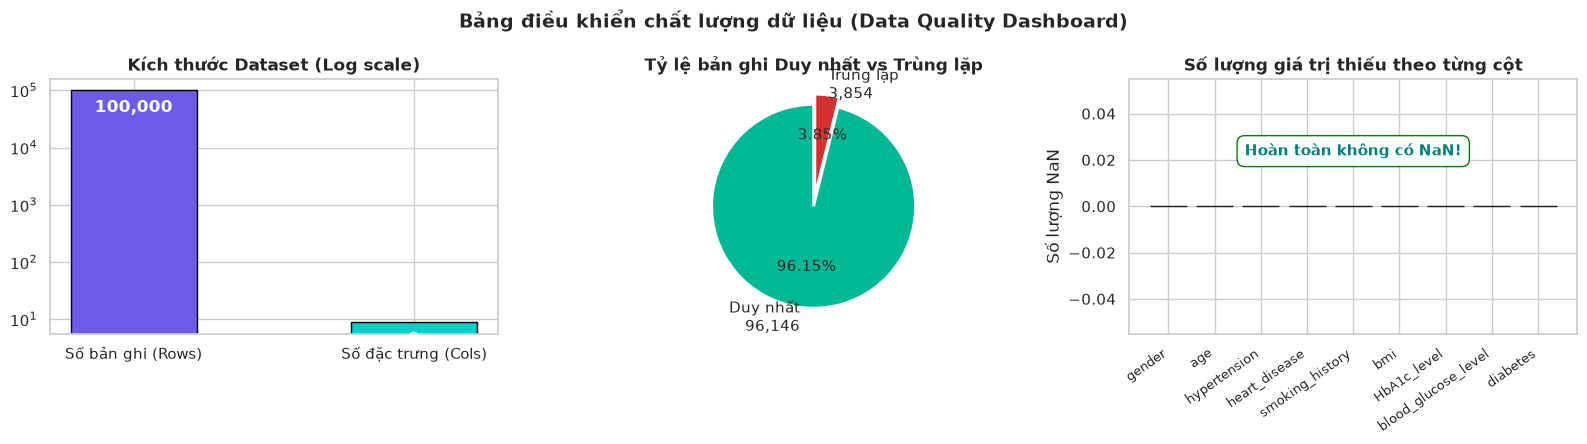

In [4]:
dup_count = int(df_raw.duplicated().sum())
missing_total = int(df_raw.isna().sum().sum())
n_rows, n_cols = len(df_raw), df_raw.shape[1]

fig, axes = plt.subplots(1, 3, figsize=(16, 4.5))

bars = axes[0].bar(['Số bản ghi (Rows)', 'Số đặc trưng (Cols)'], [n_rows, n_cols],
                   color=['#6C5CE7', '#00CEC9'], edgecolor='black', width=0.45)
for bar, v in zip(bars, [n_rows, n_cols]):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height()*0.5,
                 f'{v:,}', ha='center', va='center', fontsize=12, fontweight='bold', color='white')
axes[0].set_title('Kích thước Dataset (Log scale)')
axes[0].set_yscale('log')

unique_rows = n_rows - dup_count
axes[1].pie([unique_rows, dup_count],
            labels=[f'Duy nhất\n{unique_rows:,}', f'Trùng lặp\n{dup_count:,}'],
            colors=['#00B894', '#D63031'], autopct='%1.2f%%', startangle=90,
            explode=[0, 0.1], wedgeprops={'edgecolor': 'white', 'linewidth': 2})
axes[1].set_title('Tỷ lệ bản ghi Duy nhất vs Trùng lặp')

miss_s = df_raw.isna().sum()
col_c = ['#D63031' if v > 0 else '#00B894' for v in miss_s.values]
axes[2].bar(miss_s.index, miss_s.values, color=col_c, edgecolor='black', alpha=0.85)
axes[2].set_title('Số lượng giá trị thiếu theo từng cột')
axes[2].set_ylabel('Số lượng NaN')
plt.setp(axes[2].xaxis.get_majorticklabels(), rotation=35, ha='right', fontsize=9)
axes[2].text(0.5, 0.7, 'Hoàn toàn không có NaN!' if missing_total == 0 else f'Có {missing_total} NaN',
             transform=axes[2].transAxes, ha='center', fontsize=11, fontweight='bold',
             color='#008080' if missing_total == 0 else '#D63031',
             bbox=dict(boxstyle='round,pad=0.5', facecolor='white', edgecolor='green'))

plt.suptitle('Bảng điều khiển chất lượng dữ liệu (Data Quality Dashboard)', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig(os.path.join(MODEL_DIR, 'fig_quality_dashboard.png'), dpi=100, bbox_inches='tight')
plt.show()

## 6. Phân tích giá trị thiếu (Missing Value Analysis)

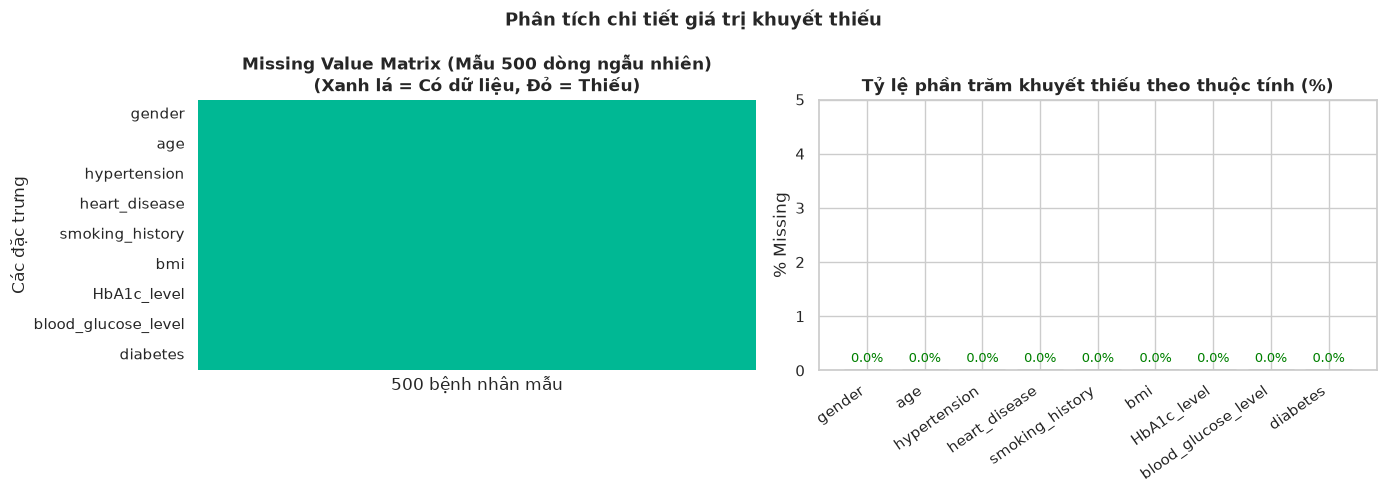

Tổng kết: 0 ô khuyết thiếu. Tập dữ liệu hoàn chỉnh.


In [5]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sample_miss = df_raw.sample(min(500, len(df_raw)), random_state=RANDOM_STATE).isnull()
sns.heatmap(sample_miss.T, cmap=['#00B894', '#D63031'], cbar=False,
            yticklabels=True, xticklabels=False, ax=axes[0], linewidths=0)
axes[0].set_title('Missing Value Matrix (Mẫu 500 dòng ngẫu nhiên)\n(Xanh lá = Có dữ liệu, Đỏ = Thiếu)')
axes[0].set_xlabel('500 bệnh nhân mẫu')
axes[0].set_ylabel('Các đặc trưng')

miss_pct = (df_raw.isna().sum() / len(df_raw) * 100).sort_values(ascending=False)
bar_c = ['#D63031' if v > 0 else '#00B894' for v in miss_pct.values]
bars = axes[1].bar(miss_pct.index, miss_pct.values, color=bar_c, edgecolor='black', alpha=0.85)
axes[1].set_title('Tỷ lệ phần trăm khuyết thiếu theo thuộc tính (%)')
axes[1].set_ylabel('% Missing')
axes[1].set_ylim(0, max(miss_pct.max() + 5, 5))
plt.setp(axes[1].xaxis.get_majorticklabels(), rotation=35, ha='right')
for bar, v in zip(bars, miss_pct.values):
    axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.1,
                 f'{v:.1f}%', ha='center', va='bottom', fontsize=9, color='green' if v == 0 else 'red')

plt.suptitle('Phân tích chi tiết giá trị khuyết thiếu', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig(os.path.join(MODEL_DIR, 'fig_missing_values.png'), dpi=100, bbox_inches='tight')
plt.show()

print(f"Tổng kết: {df_raw.isna().sum().sum()} ô khuyết thiếu. Tập dữ liệu hoàn chỉnh.")

## 7. Phân tích bản sao (Duplicate Analysis)

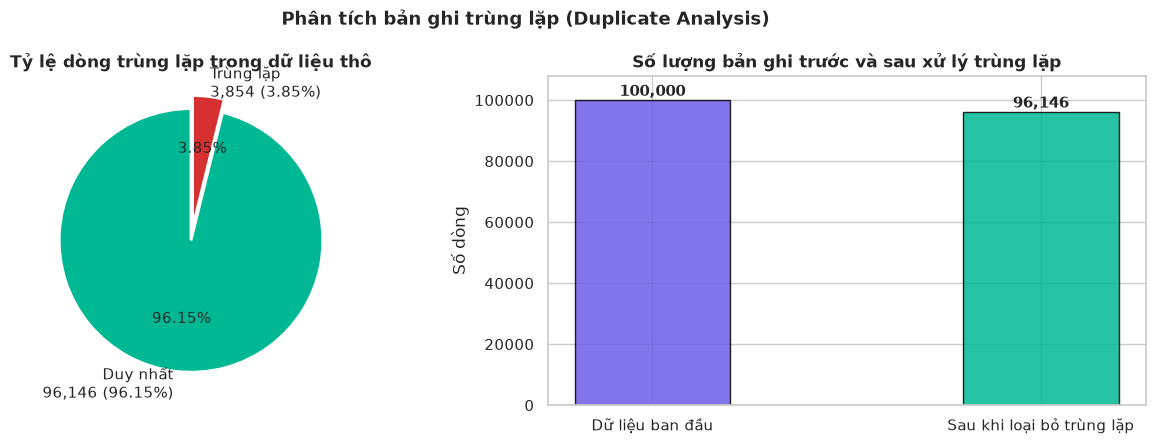

Đã làm sạch dữ liệu: Còn lại 96,146 dòng duy nhất.


In [6]:
dup_count = int(df_raw.duplicated().sum())
unique_count = len(df_raw) - dup_count

fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))

axes[0].pie([unique_count, dup_count],
            labels=[f'Duy nhất\n{unique_count:,} ({unique_count/len(df_raw)*100:.2f}%)',
                    f'Trùng lặp\n{dup_count:,} ({dup_count/len(df_raw)*100:.2f}%)'],
            colors=['#00B894', '#D63031'], autopct='%1.2f%%', startangle=90,
            explode=[0, 0.1], wedgeprops={'edgecolor': 'white', 'linewidth': 2})
axes[0].set_title('Tỷ lệ dòng trùng lặp trong dữ liệu thô')

steps_dedup = ['Dữ liệu ban đầu', 'Sau khi loại bỏ trùng lặp']
counts_dedup = [len(df_raw), unique_count]
bars_d = axes[1].bar(steps_dedup, counts_dedup, color=['#6C5CE7', '#00B894'],
                    edgecolor='black', width=0.4, alpha=0.85)
for bar, v in zip(bars_d, counts_dedup):
    axes[1].text(bar.get_x() + bar.get_width()/2, v + 200,
                 f'{v:,}', ha='center', va='bottom', fontsize=11, fontweight='bold')
axes[1].set_title('Số lượng bản ghi trước và sau xử lý trùng lặp')
axes[1].set_ylabel('Số dòng')
axes[1].set_ylim(0, len(df_raw)*1.08)

plt.suptitle('Phân tích bản ghi trùng lặp (Duplicate Analysis)', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig(os.path.join(MODEL_DIR, 'fig_duplicates.png'), dpi=100, bbox_inches='tight')
plt.show()

df_clean = df_raw.drop_duplicates().reset_index(drop=True) if dup_count > 0 else df_raw.copy()
print(f"Đã làm sạch dữ liệu: Còn lại {len(df_clean):,} dòng duy nhất.")

## 8. Phân tích giá trị không hợp lệ (Invalid Value Analysis)

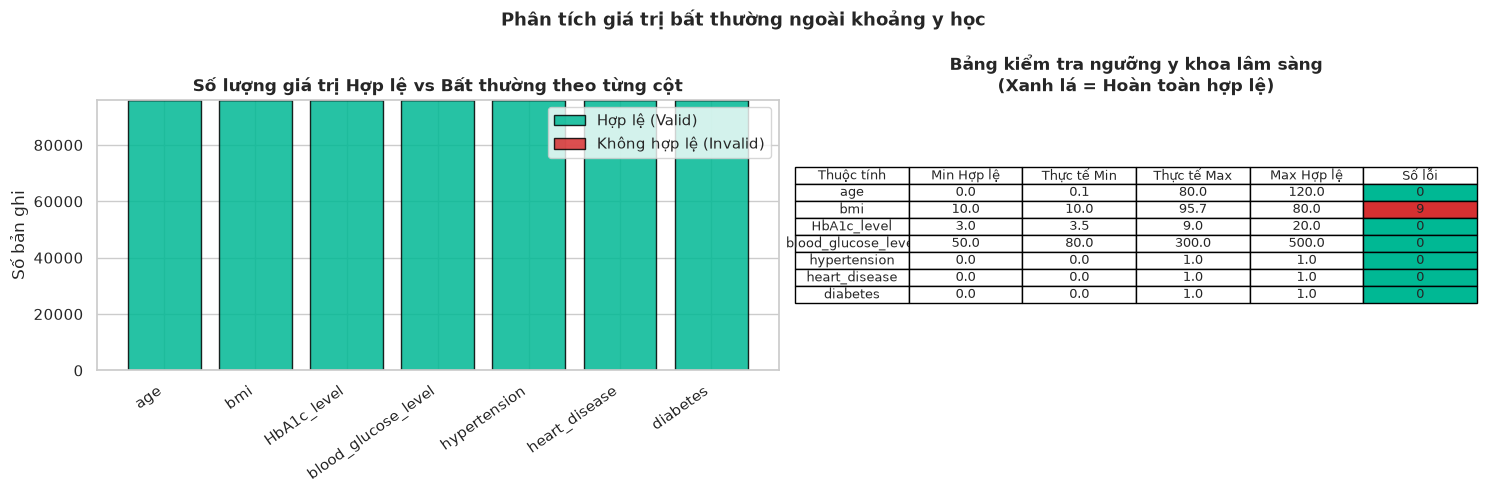

Tổng số giá trị vi phạm khoảng hợp lệ: 9
Giá trị gender: ['Female', 'Male', 'Other']
Giá trị smoking_history: ['No Info', 'current', 'ever', 'former', 'never', 'not current']


In [7]:
valid_ranges = {
    'age': (0, 120),
    'bmi': (10, 80),
    'HbA1c_level': (3.0, 20.0),
    'blood_glucose_level': (50, 500),
    'hypertension': (0, 1),
    'heart_disease': (0, 1),
    'diabetes': (0, 1)
}

invalid_counts = {c: int(((df_clean[c] < lo) | (df_clean[c] > hi)).sum()) for c, (lo, hi) in valid_ranges.items()}
valid_counts = {c: len(df_clean) - invalid_counts[c] for c in invalid_counts}

fig, axes = plt.subplots(1, 2, figsize=(15, 5))

cols_v = list(valid_ranges.keys())
axes[0].bar(cols_v, [valid_counts[c] for c in cols_v], label='Hợp lệ (Valid)',
            color='#00B894', edgecolor='black', alpha=0.85)
axes[0].bar(cols_v, [invalid_counts[c] for c in cols_v], bottom=[valid_counts[c] for c in cols_v],
            label='Không hợp lệ (Invalid)', color='#D63031', edgecolor='black', alpha=0.85)
axes[0].set_title('Số lượng giá trị Hợp lệ vs Bất thường theo từng cột')
axes[0].set_ylabel('Số bản ghi')
axes[0].legend()
plt.setp(axes[0].xaxis.get_majorticklabels(), rotation=35, ha='right')

check_df = pd.DataFrame({
    'Thuộc tính': cols_v,
    'Min Hợp lệ': [valid_ranges[c][0] for c in cols_v],
    'Thực tế Min': [df_clean[c].min().round(1) for c in cols_v],
    'Thực tế Max': [df_clean[c].max().round(1) for c in cols_v],
    'Max Hợp lệ': [valid_ranges[c][1] for c in cols_v],
    'Số lỗi': [invalid_counts[c] for c in cols_v],
})

axes[1].axis('off')
cell_colors = [['white']*5 + ['#00B894' if v == 0 else '#D63031'] for v in check_df['Số lỗi'].values]
tbl = axes[1].table(cellText=check_df.values, colLabels=check_df.columns,
                    cellLoc='center', loc='center', cellColours=cell_colors)
tbl.auto_set_font_size(False)
tbl.set_fontsize(9.5)
tbl.scale(1, 1.45)
axes[1].set_title('Bảng kiểm tra ngưỡng y khoa lâm sàng\n(Xanh lá = Hoàn toàn hợp lệ)')

plt.suptitle('Phân tích giá trị bất thường ngoài khoảng y học', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig(os.path.join(MODEL_DIR, 'fig_invalid_values.png'), dpi=100, bbox_inches='tight')
plt.show()

print(f"Tổng số giá trị vi phạm khoảng hợp lệ: {sum(invalid_counts.values())}")
print(f"Giá trị gender: {sorted(df_clean['gender'].unique())}")
print(f"Giá trị smoking_history: {sorted(df_clean['smoking_history'].unique())}")

## 9. Phân tích ngoại lệ (Outlier Analysis)

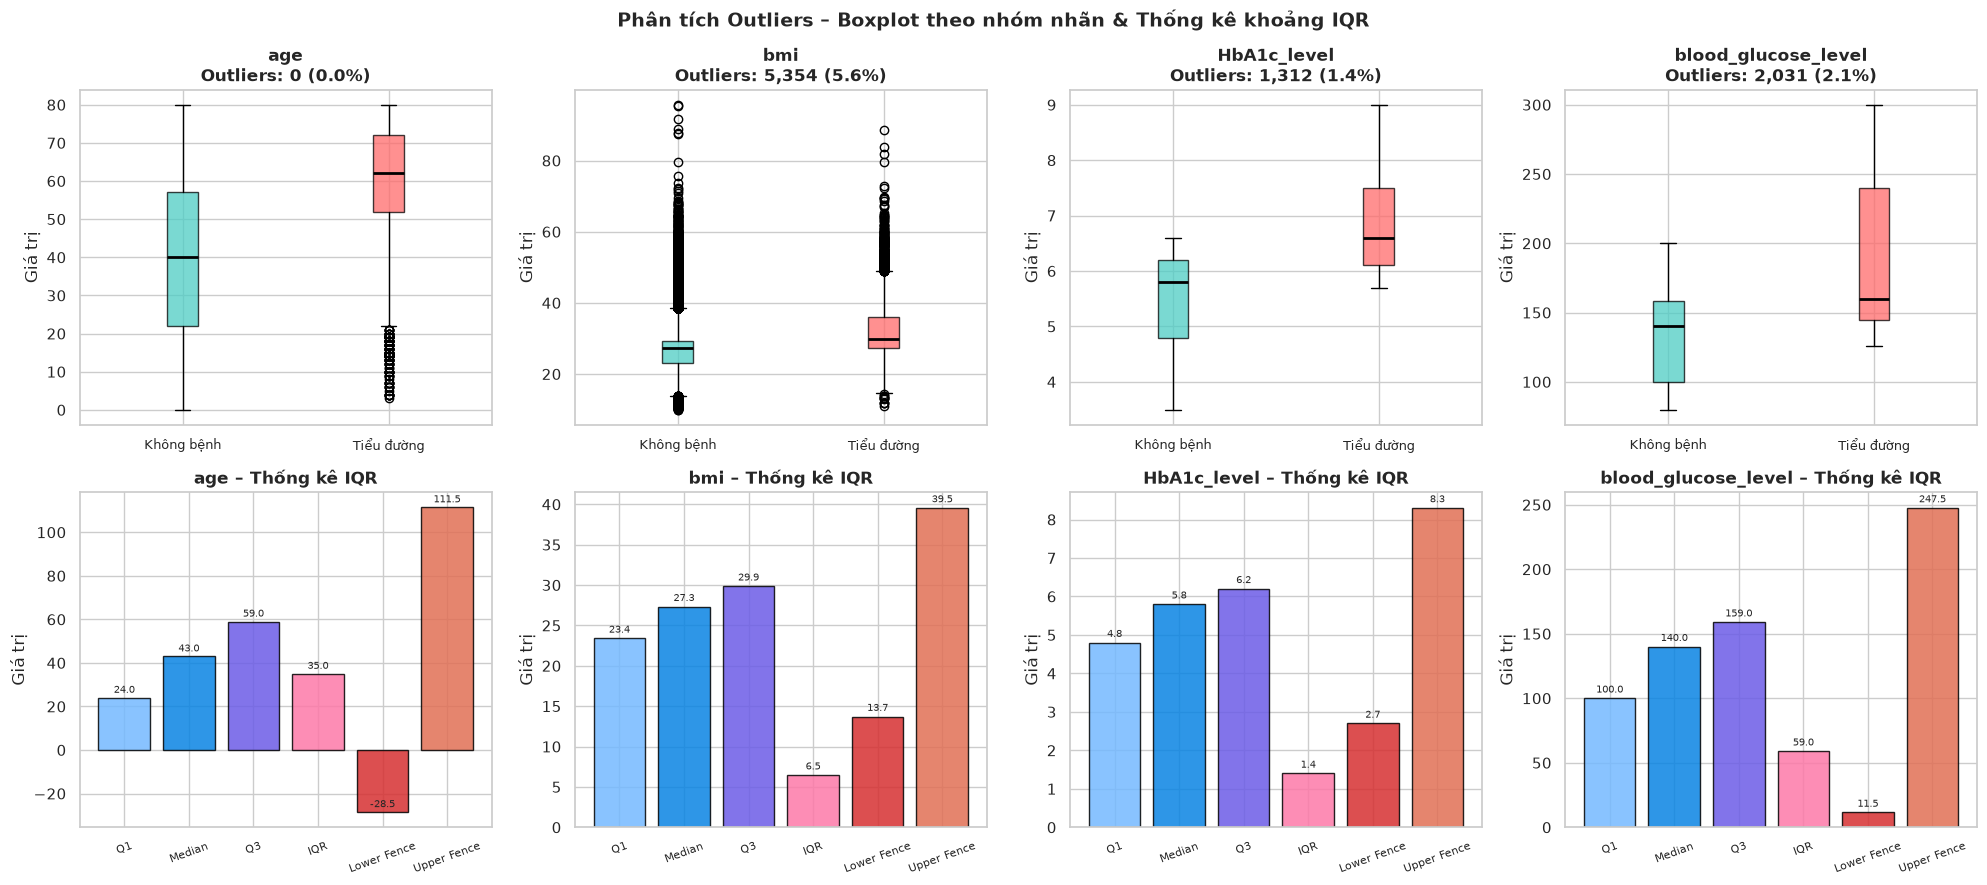

Nhận định: Các điểm outlier đại diện cho bệnh nhân có chỉ số bệnh lý cao thực tế. Không xóa bỏ.


In [8]:
out_info = {}
for col in numerical_features:
    Q1 = df_clean[col].quantile(0.25)
    Q3 = df_clean[col].quantile(0.75)
    IQR = Q3 - Q1
    lo = Q1 - 1.5 * IQR
    hi = Q3 + 1.5 * IQR
    n_out = int(((df_clean[col] < lo) | (df_clean[col] > hi)).sum())
    out_info[col] = {'Q1': Q1, 'Q3': Q3, 'IQR': IQR, 'lo': lo, 'hi': hi, 'n': n_out, 'pct': n_out/len(df_clean)*100}

fig, axes = plt.subplots(2, 4, figsize=(20, 9))

for i, col in enumerate(numerical_features):
    info = out_info[col]
    dn = df_clean[df_clean['diabetes'] == 0][col]
    dy = df_clean[df_clean['diabetes'] == 1][col]
    bp = axes[0][i].boxplot([dn, dy],
                            patch_artist=True, notch=False,
                            medianprops=dict(color='black', linewidth=2))
    axes[0][i].set_xticks([1, 2])
    axes[0][i].set_xticklabels(['Không bệnh', 'Tiểu đường'], fontsize=9.5)
    for pc, color in zip(bp['boxes'], ['#4ECDC4', '#FF6B6B']):
        pc.set_facecolor(color)
        pc.set_alpha(0.75)
    axes[0][i].set_title(f'{col}\nOutliers: {info["n"]:,} ({info["pct"]:.1f}%)')
    axes[0][i].set_ylabel('Giá trị')
    
    stat_labels = ['Q1', 'Median', 'Q3', 'IQR', 'Lower Fence', 'Upper Fence']
    stat_values = [info['Q1'], df_clean[col].median(), info['Q3'], info['IQR'], info['lo'], info['hi']]
    axes[1][i].bar(stat_labels, stat_values,
                   color=['#74B9FF', '#0984E3', '#6C5CE7', '#FD79A8', '#D63031', '#E17055'],
                   edgecolor='black', alpha=0.85)
    axes[1][i].set_title(f'{col} – Thống kê IQR')
    axes[1][i].set_ylabel('Giá trị')
    plt.setp(axes[1][i].xaxis.get_majorticklabels(), fontsize=8, rotation=20)
    for j, v in enumerate(stat_values):
        axes[1][i].text(j, v + abs(max(stat_values))*0.01, f'{v:.1f}', ha='center', va='bottom', fontsize=7.5)

plt.suptitle('Phân tích Outliers – Boxplot theo nhóm nhãn & Thống kê khoảng IQR', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig(os.path.join(MODEL_DIR, 'fig_outliers.png'), dpi=100, bbox_inches='tight')
plt.show()

print("Nhận định: Các điểm outlier đại diện cho bệnh nhân có chỉ số bệnh lý cao thực tế. Không xóa bỏ.")

## 10. Phân tích dữ liệu khám phá (Exploratory Data Analysis)

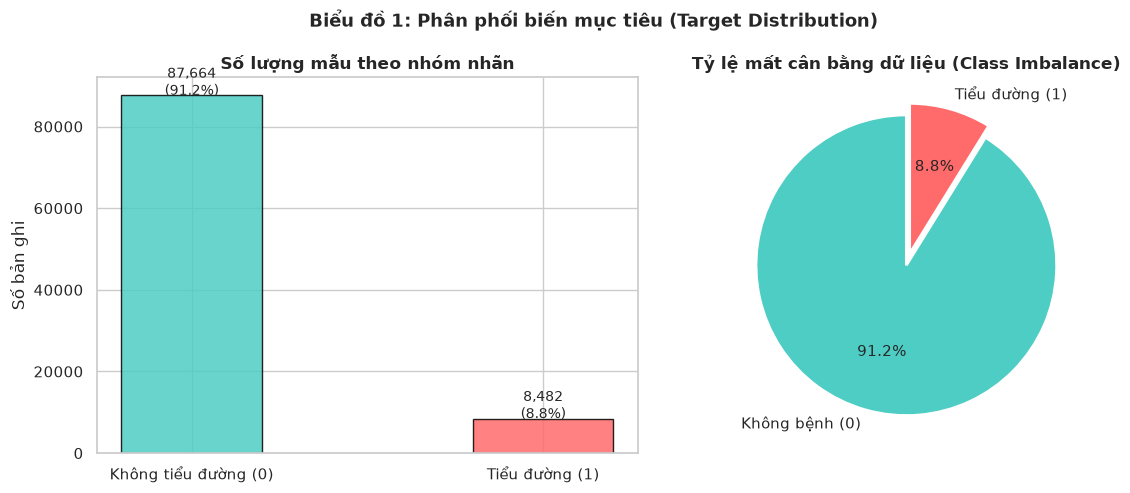

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
cc = df_clean['diabetes'].value_counts()
axes[0].bar(['Không tiểu đường (0)', 'Tiểu đường (1)'], cc.values,
            color=['#4ECDC4', '#FF6B6B'], edgecolor='black', alpha=0.85, width=0.4)
axes[0].set_title('Số lượng mẫu theo nhóm nhãn')
axes[0].set_ylabel('Số bản ghi')
for i, v in enumerate(cc.values):
    axes[0].text(i, v + 100, f'{v:,}\n({v/len(df_clean)*100:.1f}%)', ha='center', fontsize=10)

axes[1].pie(cc.values, labels=['Không bệnh (0)', 'Tiểu đường (1)'], autopct='%1.1f%%',
            colors=['#4ECDC4', '#FF6B6B'], startangle=90, explode=[0, 0.08],
            textprops={'fontsize': 11}, wedgeprops={'edgecolor': 'white', 'linewidth': 2})
axes[1].set_title('Tỷ lệ mất cân bằng dữ liệu (Class Imbalance)')

plt.suptitle('Biểu đồ 1: Phân phối biến mục tiêu (Target Distribution)', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig(os.path.join(MODEL_DIR, 'fig_eda_target.png'), dpi=100, bbox_inches='tight')
plt.show()

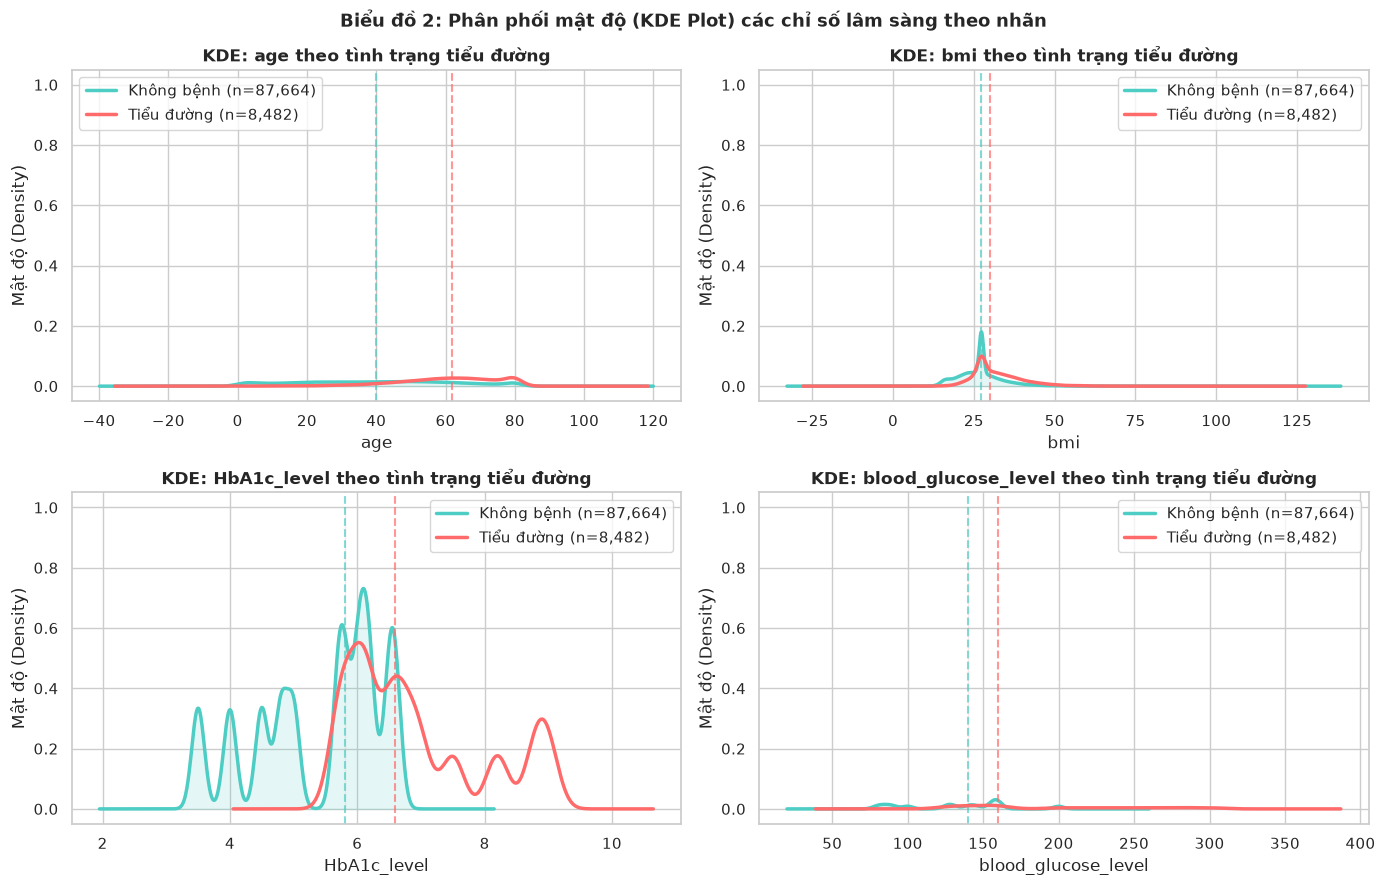

In [10]:
fig, axes = plt.subplots(2, 2, figsize=(14, 9))
axes = axes.flatten()

for i, col in enumerate(numerical_features):
    for cls, color, label in [(0, '#4ECDC4', 'Không bệnh'), (1, '#FF6B6B', 'Tiểu đường')]:
        sub = df_clean[df_clean['diabetes'] == cls][col]
        sub.plot.kde(ax=axes[i], color=color, lw=2.5, label=f'{label} (n={len(sub):,})')
        axes[i].axvline(sub.median(), color=color, linestyle='--', lw=1.5, alpha=0.7)
    axes[i].set_title(f'KDE: {col} theo tình trạng tiểu đường')
    axes[i].set_xlabel(col)
    axes[i].set_ylabel('Mật độ (Density)')
    axes[i].legend()
    lines = axes[i].lines
    if len(lines) >= 2:
        axes[i].fill_between(lines[0].get_xdata(), lines[0].get_ydata(), alpha=0.15, color='#4ECDC4')
        axes[i].fill_between(lines[1].get_xdata(), lines[1].get_ydata(), alpha=0.15, color='#FF6B6B')

plt.suptitle('Biểu đồ 2: Phân phối mật độ (KDE Plot) các chỉ số lâm sàng theo nhãn', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig(os.path.join(MODEL_DIR, 'fig_eda_distributions.png'), dpi=100, bbox_inches='tight')
plt.show()

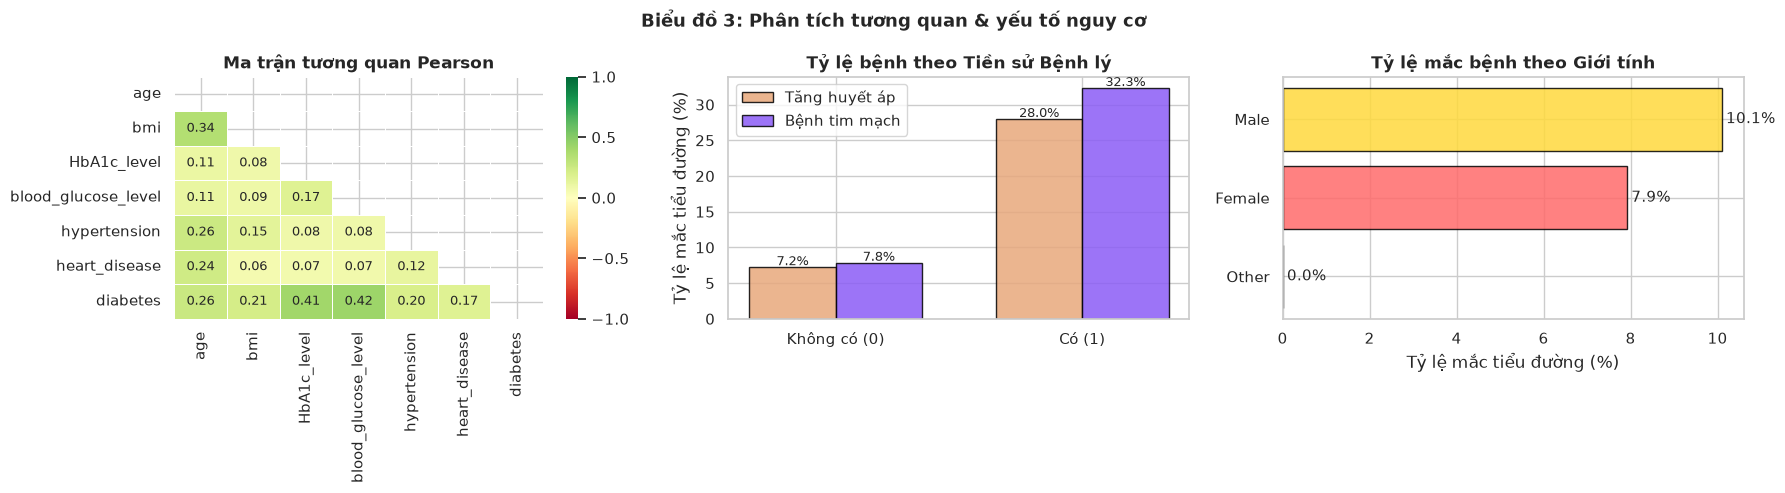

In [11]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

num_df = df_clean[numerical_features + ['hypertension', 'heart_disease', 'diabetes']]
corr = num_df.corr()
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, annot=True, fmt='.2f', cmap='RdYlGn',
            ax=axes[0], linewidths=0.5, vmin=-1, vmax=1, annot_kws={'size': 9})
axes[0].set_title('Ma trận tương quan Pearson')

ht_rate = df_clean.groupby('hypertension')['diabetes'].mean() * 100
hd_rate = df_clean.groupby('heart_disease')['diabetes'].mean() * 100
x = np.arange(2); w = 0.35
b1 = axes[1].bar(x - w/2, ht_rate.values, w, label='Tăng huyết áp', color='#E8A87C', edgecolor='black', alpha=0.85)
b2 = axes[1].bar(x + w/2, hd_rate.values, w, label='Bệnh tim mạch', color='#8B5CF6', edgecolor='black', alpha=0.85)
axes[1].set_xticks(x)
axes[1].set_xticklabels(['Không có (0)', 'Có (1)'])
axes[1].set_ylabel('Tỷ lệ mắc tiểu đường (%)')
axes[1].set_title('Tỷ lệ bệnh theo Tiền sử Bệnh lý')
axes[1].legend()
for bar in list(b1) + list(b2):
    axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.3,
                 f'{bar.get_height():.1f}%', ha='center', fontsize=9)

gender_rate = df_clean.groupby('gender')['diabetes'].mean().sort_values() * 100
g_colors = ['#4ECDC4', '#FF6B6B', '#FFD93D'][:len(gender_rate)]
axes[2].barh(gender_rate.index, gender_rate.values, color=g_colors, edgecolor='black', alpha=0.85)
axes[2].set_xlabel('Tỷ lệ mắc tiểu đường (%)')
axes[2].set_title('Tỷ lệ mắc bệnh theo Giới tính')
for i, v in enumerate(gender_rate.values):
    axes[2].text(v + 0.1, i, f'{v:.1f}%', va='center')

plt.suptitle('Biểu đồ 3: Phân tích tương quan & yếu tố nguy cơ', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig(os.path.join(MODEL_DIR, 'fig_eda_correlation.png'), dpi=100, bbox_inches='tight')
plt.show()

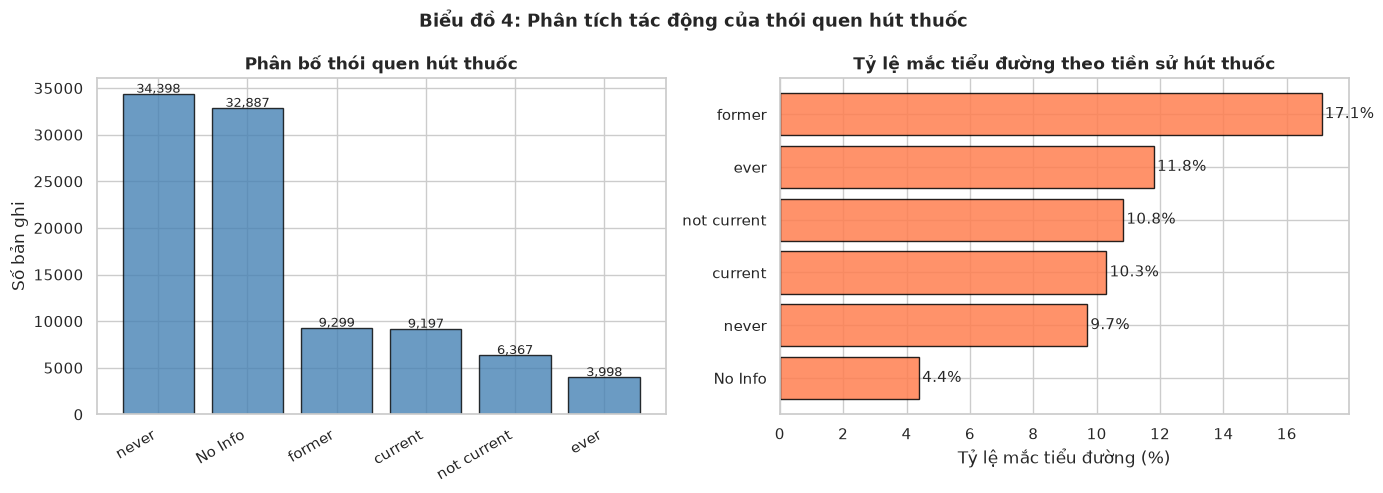

In [12]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sc = df_clean['smoking_history'].value_counts()
axes[0].bar(sc.index, sc.values, color='steelblue', alpha=0.8, edgecolor='black')
axes[0].set_title('Phân bố thói quen hút thuốc')
axes[0].set_ylabel('Số bản ghi')
plt.setp(axes[0].xaxis.get_majorticklabels(), rotation=30, ha='right')
for i, v in enumerate(sc.values):
    axes[0].text(i, v + 100, f'{v:,}', ha='center', fontsize=9)

sr = df_clean.groupby('smoking_history')['diabetes'].mean().sort_values() * 100
axes[1].barh(sr.index, sr.values, color='coral', alpha=0.85, edgecolor='black')
axes[1].set_xlabel('Tỷ lệ mắc tiểu đường (%)')
axes[1].set_title('Tỷ lệ mắc tiểu đường theo tiền sử hút thuốc')
for i, v in enumerate(sr.values):
    axes[1].text(v + 0.1, i, f'{v:.1f}%', va='center')

plt.suptitle('Biểu đồ 4: Phân tích tác động của thói quen hút thuốc', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig(os.path.join(MODEL_DIR, 'fig_eda_smoking.png'), dpi=100, bbox_inches='tight')
plt.show()

## 11. Các loại đặc trưng (Feature Types)

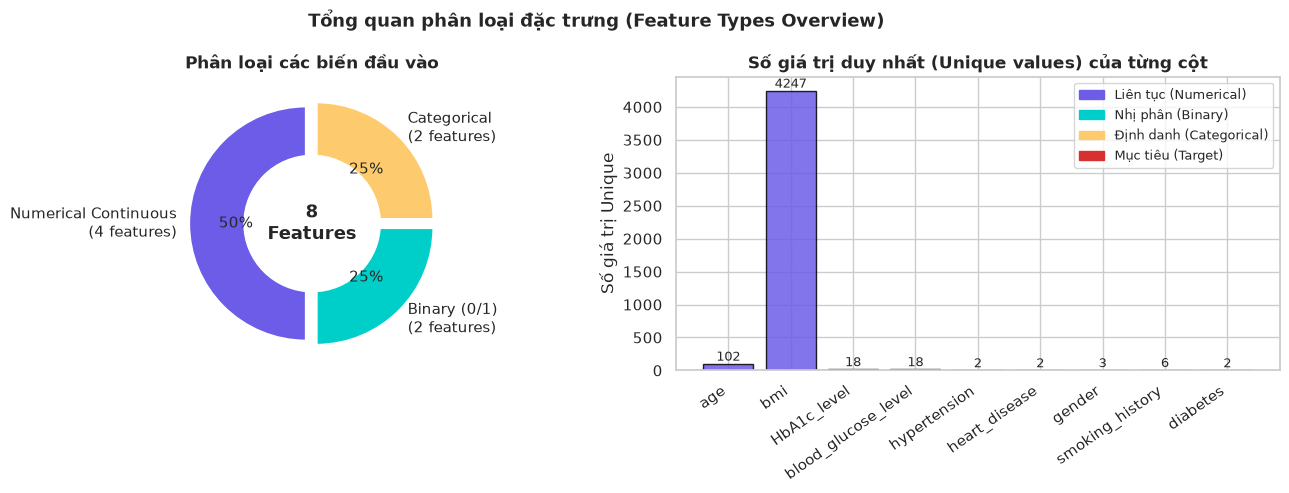

In [13]:
NUMERICAL_CONTINUOUS = ['age', 'bmi', 'HbA1c_level', 'blood_glucose_level']
BINARY_FEATURES = ['hypertension', 'heart_disease']
CATEGORICAL_FEATURES = ['gender', 'smoking_history']
TARGET = 'diabetes'
ALL_FEATURES = NUMERICAL_CONTINUOUS + BINARY_FEATURES + CATEGORICAL_FEATURES

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

type_sizes = [len(NUMERICAL_CONTINUOUS), len(BINARY_FEATURES), len(CATEGORICAL_FEATURES)]
type_labels = ['Numerical Continuous', 'Binary (0/1)', 'Categorical']
type_colors = ['#6C5CE7', '#00CEC9', '#FDCB6E']

axes[0].pie(type_sizes, labels=[f'{l}\n({s} features)' for l, s in zip(type_labels, type_sizes)],
            colors=type_colors, autopct='%1.0f%%', startangle=90,
            explode=[0.05]*3, wedgeprops={'edgecolor': 'white', 'linewidth': 2})
axes[0].add_patch(plt.Circle((0, 0), 0.58, fc='white'))
axes[0].text(0, 0, f'{len(ALL_FEATURES)}\nFeatures', ha='center', va='center', fontsize=13, fontweight='bold')
axes[0].set_title('Phân loại các biến đầu vào')

all_f = ALL_FEATURES + [TARGET]
n_u = [df_clean[f].nunique() for f in all_f]
fmap = {f: '#6C5CE7' for f in NUMERICAL_CONTINUOUS}
fmap.update({f: '#00CEC9' for f in BINARY_FEATURES})
fmap.update({f: '#FDCB6E' for f in CATEGORICAL_FEATURES})
fmap[TARGET] = '#D63031'

fc = [fmap[f] for f in all_f]
bars = axes[1].bar(all_f, n_u, color=fc, edgecolor='black', alpha=0.85)
axes[1].set_title('Số giá trị duy nhất (Unique values) của từng cột')
axes[1].set_ylabel('Số giá trị Unique')
plt.setp(axes[1].xaxis.get_majorticklabels(), rotation=35, ha='right')
for bar, v in zip(bars, n_u):
    axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5, str(v), ha='center', va='bottom', fontsize=9)

legend_patches = [
    mpatches.Patch(color='#6C5CE7', label='Liên tục (Numerical)'),
    mpatches.Patch(color='#00CEC9', label='Nhị phân (Binary)'),
    mpatches.Patch(color='#FDCB6E', label='Định danh (Categorical)'),
    mpatches.Patch(color='#D63031', label='Mục tiêu (Target)')
]
axes[1].legend(handles=legend_patches, loc='upper right', fontsize=9)

plt.suptitle('Tổng quan phân loại đặc trưng (Feature Types Overview)', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig(os.path.join(MODEL_DIR, 'fig_feature_types.png'), dpi=100, bbox_inches='tight')
plt.show()

## 12. Biểu diễn dữ liệu (Data Representation) ⭐

Liên hệ kiến thức **Lecture 02**:
- Mỗi bệnh nhân $i$ là một vector đặc trưng: $\mathbf{x}_i = [x_{i1}, x_{i2}, \ldots, x_{id}]^\top \in \mathbb{R}^d$
- Không gian tập dữ liệu: $\mathbf{X} \in \mathbb{R}^{N \times d}$, nhãn mục tiêu $\mathbf{y} \in \{0, 1\}^N$

In [14]:
sample_idx = 7
X = df_clean[ALL_FEATURES]
y = df_clean[TARGET]

print("Mẫu dữ liệu thực tế (dòng thô):")
print(df_clean.iloc[sample_idx])
print()
print(f"Không gian dữ liệu thô: X shape = {X.shape} (N={X.shape[0]:,}, d_raw={X.shape[1]})")
print(f"Nhãn mục tiêu: y shape = {y.shape}")

Mẫu dữ liệu thực tế (dòng thô):
gender                  Female
age                       79.0
hypertension                 0
heart_disease                0
smoking_history        No Info
bmi                      23.86
HbA1c_level                5.7
blood_glucose_level         85
diabetes                     0
Name: 7, dtype: object

Không gian dữ liệu thô: X shape = (96146, 8) (N=96,146, d_raw=8)
Nhãn mục tiêu: y shape = (96146,)


## 13. Kỹ thuật đặc trưng (Feature Engineering)

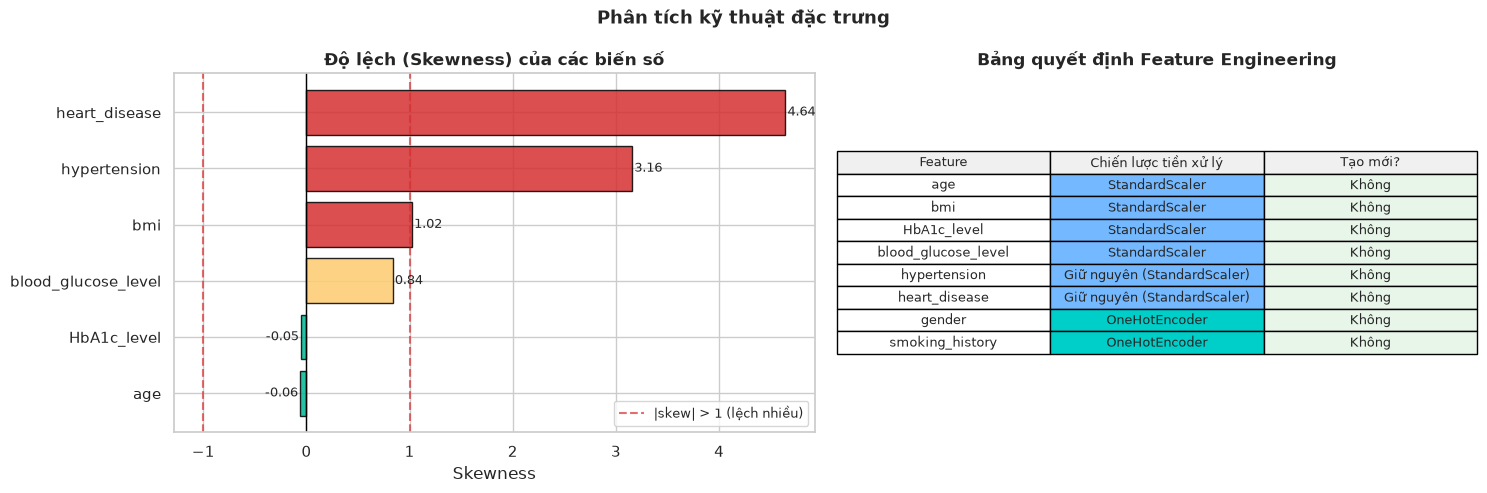

In [15]:
NUMERICAL_PIPELINE_COLS = NUMERICAL_CONTINUOUS + BINARY_FEATURES
CATEGORICAL_PIPELINE_COLS = CATEGORICAL_FEATURES

fig, axes = plt.subplots(1, 2, figsize=(15, 5))

skew_v = df_clean[NUMERICAL_PIPELINE_COLS].skew().sort_values()
sc_colors = ['#D63031' if abs(v) > 1 else '#00B894' if abs(v) < 0.5 else '#FDCB6E' for v in skew_v.values]
axes[0].barh(skew_v.index, skew_v.values, color=sc_colors, edgecolor='black', alpha=0.85)
axes[0].axvline(0, color='black', lw=1)
axes[0].axvline(1, color='#D63031', lw=1.5, linestyle='--', alpha=0.7, label='|skew| > 1 (lệch nhiều)')
axes[0].axvline(-1, color='#D63031', lw=1.5, linestyle='--', alpha=0.7)
axes[0].set_title('Độ lệch (Skewness) của các biến số')
axes[0].set_xlabel('Skewness')
axes[0].legend(fontsize=9)
for bar, v in zip(axes[0].patches, skew_v.values):
    axes[0].text(v + (0.02 if v >= 0 else -0.02), bar.get_y() + bar.get_height()/2,
                 f'{v:.2f}', va='center', ha='left' if v >= 0 else 'right', fontsize=9)

fe_table = [
    ['age', 'StandardScaler', 'Không'],
    ['bmi', 'StandardScaler', 'Không'],
    ['HbA1c_level', 'StandardScaler', 'Không'],
    ['blood_glucose_level', 'StandardScaler', 'Không'],
    ['hypertension', 'Giữ nguyên (StandardScaler)', 'Không'],
    ['heart_disease', 'Giữ nguyên (StandardScaler)', 'Không'],
    ['gender', 'OneHotEncoder', 'Không'],
    ['smoking_history', 'OneHotEncoder', 'Không'],
]
action_c = ['#74B9FF' if 'Scaler' in r[1] else '#00CEC9' for r in fe_table]
cell_c = [['white', c, '#E8F5E9'] for c in action_c]
axes[1].axis('off')
tbl = axes[1].table(cellText=fe_table, colLabels=['Feature', 'Chiến lược tiền xử lý', 'Tạo mới?'],
                    cellLoc='center', loc='center', cellColours=cell_c, colColours=['#F0F0F0']*3)
tbl.auto_set_font_size(False)
tbl.set_fontsize(9.5)
tbl.scale(1, 1.45)
axes[1].set_title('Bảng quyết định Feature Engineering')

plt.suptitle('Phân tích kỹ thuật đặc trưng', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig(os.path.join(MODEL_DIR, 'fig_feature_engineering.png'), dpi=100, bbox_inches='tight')
plt.show()

## 14. Chia tập train/test (Train/Test Split)

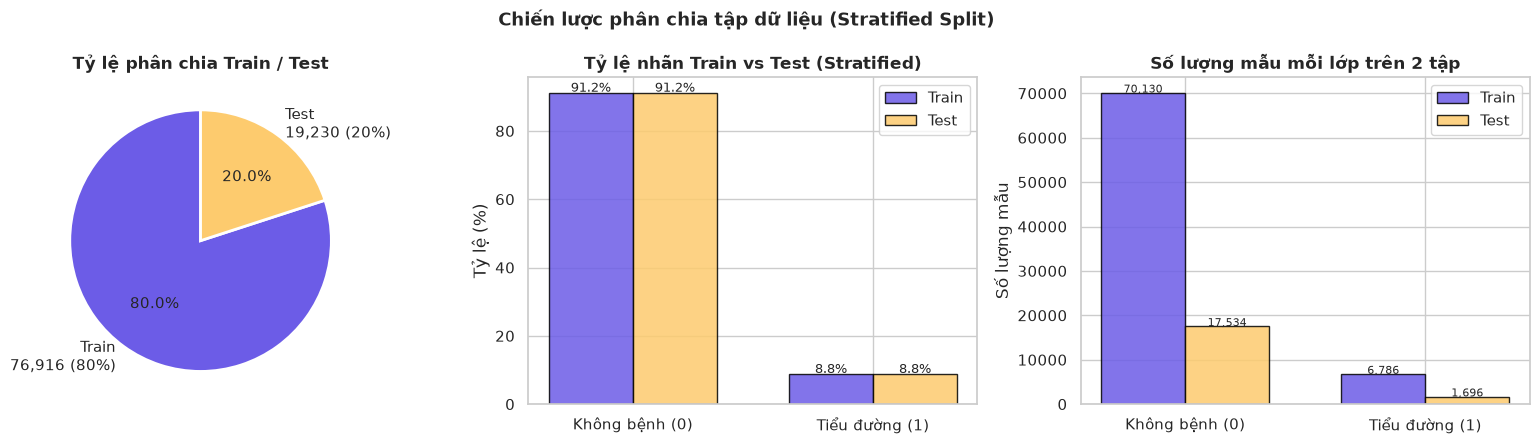

X_train shape: (76916, 8) | X_test shape: (19230, 8)


In [16]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=RANDOM_STATE, stratify=y
)

fig, axes = plt.subplots(1, 3, figsize=(16, 4.5))

axes[0].pie([len(X_train), len(X_test)],
            labels=[f'Train\n{len(X_train):,} (80%)', f'Test\n{len(X_test):,} (20%)'],
            colors=['#6C5CE7', '#FDCB6E'], autopct='%1.1f%%', startangle=90,
            wedgeprops={'edgecolor': 'white', 'linewidth': 2})
axes[0].set_title('Tỷ lệ phân chia Train / Test')

trd = y_train.value_counts(normalize=True) * 100
tsd = y_test.value_counts(normalize=True) * 100
x = np.arange(2); w = 0.35
b1 = axes[1].bar(x - w/2, [trd[0], trd[1]], w, label='Train', color='#6C5CE7', edgecolor='black', alpha=0.85)
b2 = axes[1].bar(x + w/2, [tsd[0], tsd[1]], w, label='Test', color='#FDCB6E', edgecolor='black', alpha=0.85)
axes[1].set_xticks(x)
axes[1].set_xticklabels(['Không bệnh (0)', 'Tiểu đường (1)'])
axes[1].set_ylabel('Tỷ lệ (%)')
axes[1].set_title('Tỷ lệ nhãn Train vs Test (Stratified)')
axes[1].legend()
for bar in list(b1) + list(b2):
    axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.3,
                 f'{bar.get_height():.1f}%', ha='center', fontsize=9)

tc = y_train.value_counts().sort_index()
sc = y_test.value_counts().sort_index()
c1 = axes[2].bar(x - w/2, tc.values, w, label='Train', color='#6C5CE7', edgecolor='black', alpha=0.85)
c2 = axes[2].bar(x + w/2, sc.values, w, label='Test', color='#FDCB6E', edgecolor='black', alpha=0.85)
axes[2].set_xticks(x)
axes[2].set_xticklabels(['Không bệnh (0)', 'Tiểu đường (1)'])
axes[2].set_ylabel('Số lượng mẫu')
axes[2].set_title('Số lượng mẫu mỗi lớp trên 2 tập')
axes[2].legend()
for bar in list(c1) + list(c2):
    axes[2].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 30,
                 f'{int(bar.get_height()):,}', ha='center', fontsize=8)

plt.suptitle('Chiến lược phân chia tập dữ liệu (Stratified Split)', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig(os.path.join(MODEL_DIR, 'fig_train_test_split.png'), dpi=100, bbox_inches='tight')
plt.show()

print(f"X_train shape: {X_train.shape} | X_test shape: {X_test.shape}")

## 15. Pipeline tiền xử lý (Preprocessing Pipeline)

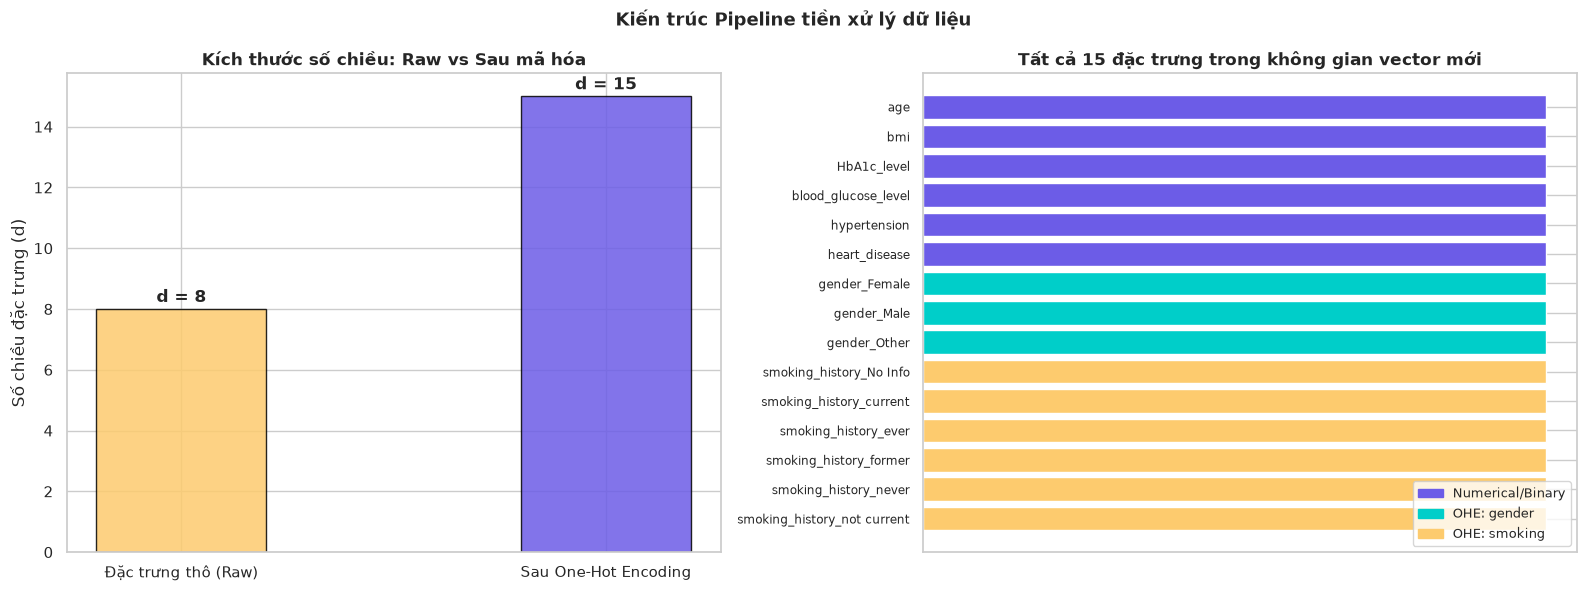

X_train_proc shape: (76916, 15) | X_test_proc shape: (19230, 15)


In [17]:
preprocessor = ColumnTransformer(transformers=[
    ('num', Pipeline([('scaler', StandardScaler())]), NUMERICAL_PIPELINE_COLS),
    ('cat', Pipeline([('ohe', OneHotEncoder(handle_unknown='ignore', sparse_output=False))]), CATEGORICAL_PIPELINE_COLS),
], remainder='drop')

preprocessor.fit(X_train)
X_train_proc = preprocessor.transform(X_train)
X_test_proc = preprocessor.transform(X_test)

cat_names = preprocessor.named_transformers_['cat']['ohe'].get_feature_names_out(CATEGORICAL_PIPELINE_COLS)
all_feature_names = NUMERICAL_PIPELINE_COLS + list(cat_names)
d = len(all_feature_names)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

axes[0].bar(['Đặc trưng thô (Raw)', 'Sau One-Hot Encoding'], [len(ALL_FEATURES), d],
            color=['#FDCB6E', '#6C5CE7'], edgecolor='black', width=0.4, alpha=0.85)
axes[0].set_title('Kích thước số chiều: Raw vs Sau mã hóa')
axes[0].set_ylabel('Số chiều đặc trưng (d)')
for bar, v in zip(axes[0].patches, [len(ALL_FEATURES), d]):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.1,
                 f'd = {v}', ha='center', va='bottom', fontsize=12, fontweight='bold')

origins = (['Numerical/Binary'] * len(NUMERICAL_PIPELINE_COLS)
           + ['OHE: gender'] * len([f for f in all_feature_names if 'gender' in f])
           + ['OHE: smoking'] * len([f for f in all_feature_names if 'smoking' in f]))
oc = {'Numerical/Binary': '#6C5CE7', 'OHE: gender': '#00CEC9', 'OHE: smoking': '#FDCB6E'}
fc_bar = [oc.get(o, '#ccc') for o in origins]
axes[1].barh(np.arange(d), [1]*d, color=fc_bar, edgecolor='white', height=0.8)
axes[1].set_yticks(np.arange(d))
axes[1].set_yticklabels(all_feature_names, fontsize=8.5)
axes[1].set_title(f'Tất cả {d} đặc trưng trong không gian vector mới')
axes[1].invert_yaxis()
axes[1].set_xticks([])
lp = [mpatches.Patch(color=c, label=l) for l, c in oc.items()]
axes[1].legend(handles=lp, loc='lower right', fontsize=9)

plt.suptitle('Kiến trúc Pipeline tiền xử lý dữ liệu', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig(os.path.join(MODEL_DIR, 'fig_pipeline.png'), dpi=100, bbox_inches='tight')
plt.show()

print(f"X_train_proc shape: {X_train_proc.shape} | X_test_proc shape: {X_test_proc.shape}")

## 12b. Biểu diễn dữ liệu – Tiếp theo (Sau Preprocessing)

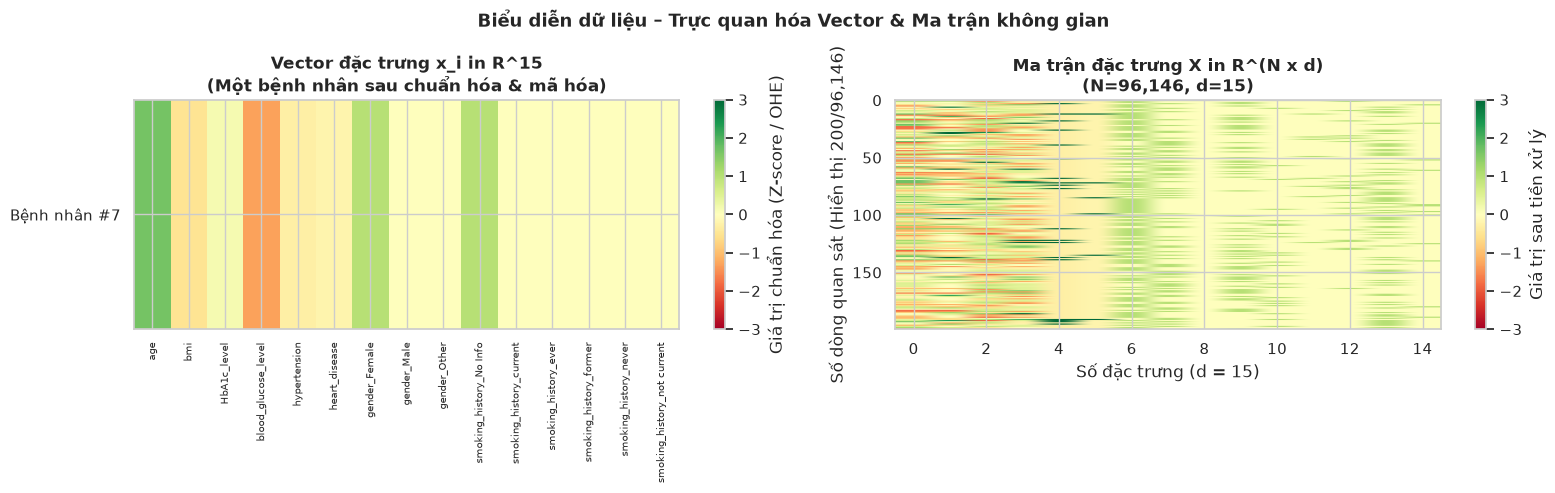

In [18]:
sample_proc = preprocessor.transform(X.iloc[[sample_idx]])
d_real = sample_proc.shape[1]
N_total = X_train_proc.shape[0] + X_test_proc.shape[0]

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

im = axes[0].imshow(sample_proc, cmap='RdYlGn', aspect='auto', vmin=-3, vmax=3)
axes[0].set_yticks([0])
axes[0].set_yticklabels([f'Bệnh nhân #{sample_idx}'])
axes[0].set_xticks(range(d_real))
axes[0].set_xticklabels(all_feature_names, rotation=90, fontsize=7.5)
axes[0].set_title(f'Vector đặc trưng x_i in R^{d_real}\n(Một bệnh nhân sau chuẩn hóa & mã hóa)')
plt.colorbar(im, ax=axes[0], label='Giá trị chuẩn hóa (Z-score / OHE)')

n_show = 200
im2 = axes[1].imshow(X_train_proc[:n_show], cmap='RdYlGn', aspect='auto', vmin=-3, vmax=3)
axes[1].set_xlabel(f'Số đặc trưng (d = {d_real})')
axes[1].set_ylabel(f'Số dòng quan sát (Hiển thị {n_show}/{N_total:,})')
axes[1].set_title(f'Ma trận đặc trưng X in R^(N x d)\n(N={N_total:,}, d={d_real})')
plt.colorbar(im2, ax=axes[1], label='Giá trị sau tiền xử lý')

plt.suptitle('Biểu diễn dữ liệu – Trực quan hóa Vector & Ma trận không gian', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig(os.path.join(MODEL_DIR, 'fig_data_representation.png'), dpi=100, bbox_inches='tight')
plt.show()

## 16. Mô hình cơ sở (Baseline Model)

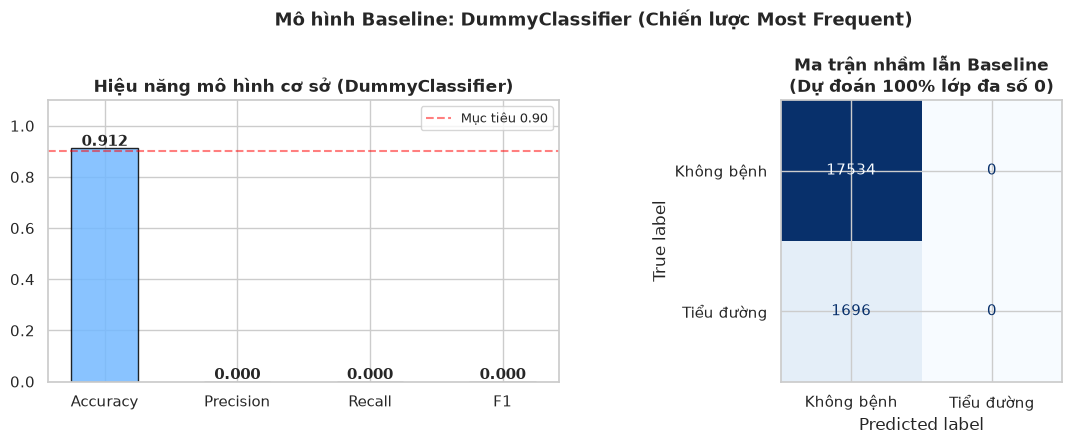

Nhận xét: Baseline có Accuracy cao giả tạo (~91.5%) nhưng Recall=0, F1=0. Hoàn toàn vô dụng trong y tế.


In [19]:
baseline = DummyClassifier(strategy='most_frequent', random_state=RANDOM_STATE)
baseline.fit(X_train_proc, y_train)
y_bl = baseline.predict(X_test_proc)

bl_m = {
    'Accuracy': accuracy_score(y_test, y_bl),
    'Precision': precision_score(y_test, y_bl, zero_division=0),
    'Recall': recall_score(y_test, y_bl, zero_division=0),
    'F1': f1_score(y_test, y_bl, zero_division=0)
}

fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))

bars = axes[0].bar(bl_m.keys(), bl_m.values(),
                   color=['#74B9FF', '#FD79A8', '#55EFC4', '#FFEAA7'],
                   edgecolor='black', alpha=0.85, width=0.5)
axes[0].set_ylim(0, 1.1)
axes[0].set_title('Hiệu năng mô hình cơ sở (DummyClassifier)')
axes[0].axhline(0.9, color='red', linestyle='--', alpha=0.5, label='Mục tiêu 0.90')
axes[0].legend(fontsize=9)
for bar, v in zip(bars, bl_m.values()):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
                 f'{v:.3f}', ha='center', fontsize=11, fontweight='bold')

cm_bl = confusion_matrix(y_test, y_bl)
ConfusionMatrixDisplay(cm_bl, display_labels=['Không bệnh', 'Tiểu đường']).plot(
    ax=axes[1], colorbar=False, cmap='Blues')
axes[1].set_title('Ma trận nhầm lẫn Baseline\n(Dự đoán 100% lớp đa số 0)')

plt.suptitle('Mô hình Baseline: DummyClassifier (Chiến lược Most Frequent)', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig(os.path.join(MODEL_DIR, 'fig_baseline.png'), dpi=100, bbox_inches='tight')
plt.show()

print("Nhận xét: Baseline có Accuracy cao giả tạo (~91.5%) nhưng Recall=0, F1=0. Hoàn toàn vô dụng trong y tế.")

## 17. Huấn luyện mô hình (Model Training)

In [20]:
trained_models = {}
train_times = {}
train_accs = {}
test_accs = {}

model_configs = [
    ('Logistic Regression', LogisticRegression(class_weight='balanced', max_iter=1000,
                                                random_state=RANDOM_STATE, solver='saga', n_jobs=-1)),
    ('Decision Tree', DecisionTreeClassifier(max_depth=10, class_weight='balanced',
                                              random_state=RANDOM_STATE)),
    ('Random Forest', RandomForestClassifier(n_estimators=100, max_depth=15,
                                              class_weight='balanced',
                                              random_state=RANDOM_STATE, n_jobs=-1)),
    ('SVM (LinearSVC)', CalibratedClassifierCV(
        LinearSVC(class_weight='balanced', max_iter=2000, random_state=RANDOM_STATE), cv=3)),
    ('KNN', KNeighborsClassifier(n_neighbors=11, weights='distance', n_jobs=-1, leaf_size=40)),
]

print("Bắt đầu huấn luyện 5 mô hình...")
for name, model in model_configs:
    t0 = time.time()
    model.fit(X_train_proc, y_train)
    elapsed = time.time() - t0
    trained_models[name] = model
    train_times[name] = elapsed
    train_accs[name] = model.score(X_train_proc, y_train)
    test_accs[name] = model.score(X_test_proc, y_test)
    print(f"  ✓ {name:20s}: {elapsed:6.1f}s | Train Acc: {train_accs[name]:.4f} | Test Acc: {test_accs[name]:.4f}")

Bắt đầu huấn luyện 5 mô hình...


  ✓ Logistic Regression :    8.2s | Train Acc: 0.8871 | Test Acc: 0.8846


  ✓ Decision Tree       :    0.3s | Train Acc: 0.8893 | Test Acc: 0.8806


  ✓ Random Forest       :    1.5s | Train Acc: 0.9369 | Test Acc: 0.9174


  ✓ SVM (LinearSVC)     :    0.7s | Train Acc: 0.9579 | Test Acc: 0.9588


  ✓ KNN                 :    0.3s | Train Acc: 0.9991 | Test Acc: 0.9602


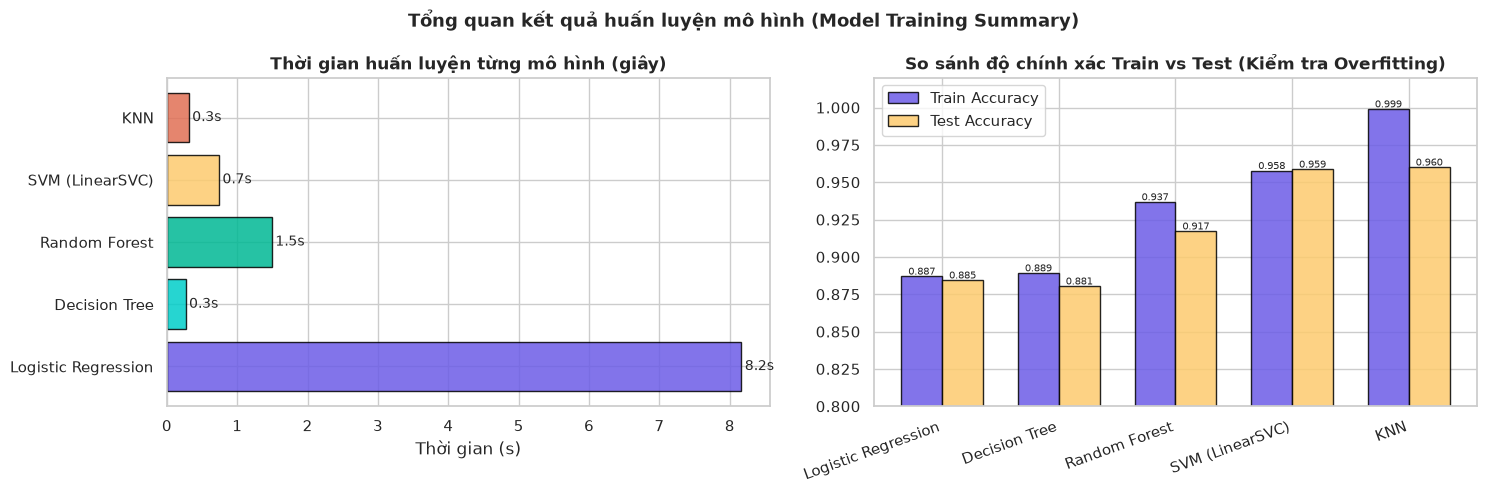

In [21]:
model_names = list(trained_models.keys())
colors_m = ['#6C5CE7', '#00CEC9', '#00B894', '#FDCB6E', '#E17055']

fig, axes = plt.subplots(1, 2, figsize=(15, 5))

times_v = [train_times[n] for n in model_names]
bars_t = axes[0].barh(model_names, times_v, color=colors_m, edgecolor='black', alpha=0.85)
for bar, v in zip(bars_t, times_v):
    axes[0].text(bar.get_width() + 0.05, bar.get_y() + bar.get_height()/2,
                 f'{v:.1f}s', va='center', fontsize=10)
axes[0].set_title('Thời gian huấn luyện từng mô hình (giây)')
axes[0].set_xlabel('Thời gian (s)')

xp = np.arange(len(model_names)); w = 0.35
b_tr = axes[1].bar(xp - w/2, [train_accs[n] for n in model_names], w,
                   label='Train Accuracy', color='#6C5CE7', edgecolor='black', alpha=0.85)
b_te = axes[1].bar(xp + w/2, [test_accs[n] for n in model_names], w,
                   label='Test Accuracy', color='#FDCB6E', edgecolor='black', alpha=0.85)
axes[1].set_xticks(xp)
axes[1].set_xticklabels(model_names, rotation=20, ha='right')
axes[1].set_ylim(0.8, 1.02)
axes[1].set_title('So sánh độ chính xác Train vs Test (Kiểm tra Overfitting)')
axes[1].legend()
for b in list(b_tr) + list(b_te):
    axes[1].text(b.get_x() + b.get_width()/2, b.get_height() + 0.001,
                 f'{b.get_height():.3f}', ha='center', fontsize=7.5)

plt.suptitle('Tổng quan kết quả huấn luyện mô hình (Model Training Summary)', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig(os.path.join(MODEL_DIR, 'fig_training_summary.png'), dpi=100, bbox_inches='tight')
plt.show()

## 18. So sánh mô hình (Model Comparison)

In [22]:
def evaluate_model(name, model, X_te, y_te):
    yp = model.predict(X_te)
    yb = model.predict_proba(X_te)[:, 1] if hasattr(model, 'predict_proba') else model.decision_function(X_te)
    return {
        'Model': name,
        'Accuracy': accuracy_score(y_te, yp),
        'Precision': precision_score(y_te, yp, zero_division=0),
        'Recall': recall_score(y_te, yp, zero_division=0),
        'F1': f1_score(y_te, yp, zero_division=0),
        'ROC-AUC': roc_auc_score(y_te, yb)
    }

results = [evaluate_model(n, m, X_test_proc, y_test) for n, m in trained_models.items()]
comparison_df = pd.DataFrame(results).set_index('Model').round(4)
comparison_df

,Accuracy,Precision,Recall,F1,ROC-AUC
Model,,,,,
Logistic Regression,0.8846,0.4253,0.8797,0.5734,0.9601
Decision Tree,0.8806,0.4189,0.9151,0.5747,0.9704
Random Forest,0.9174,0.5189,0.8679,0.6495,0.9738
SVM (LinearSVC),0.9588,0.8604,0.6362,0.7315,0.9600
KNN,0.9602,0.9167,0.6032,0.7276,0.9294


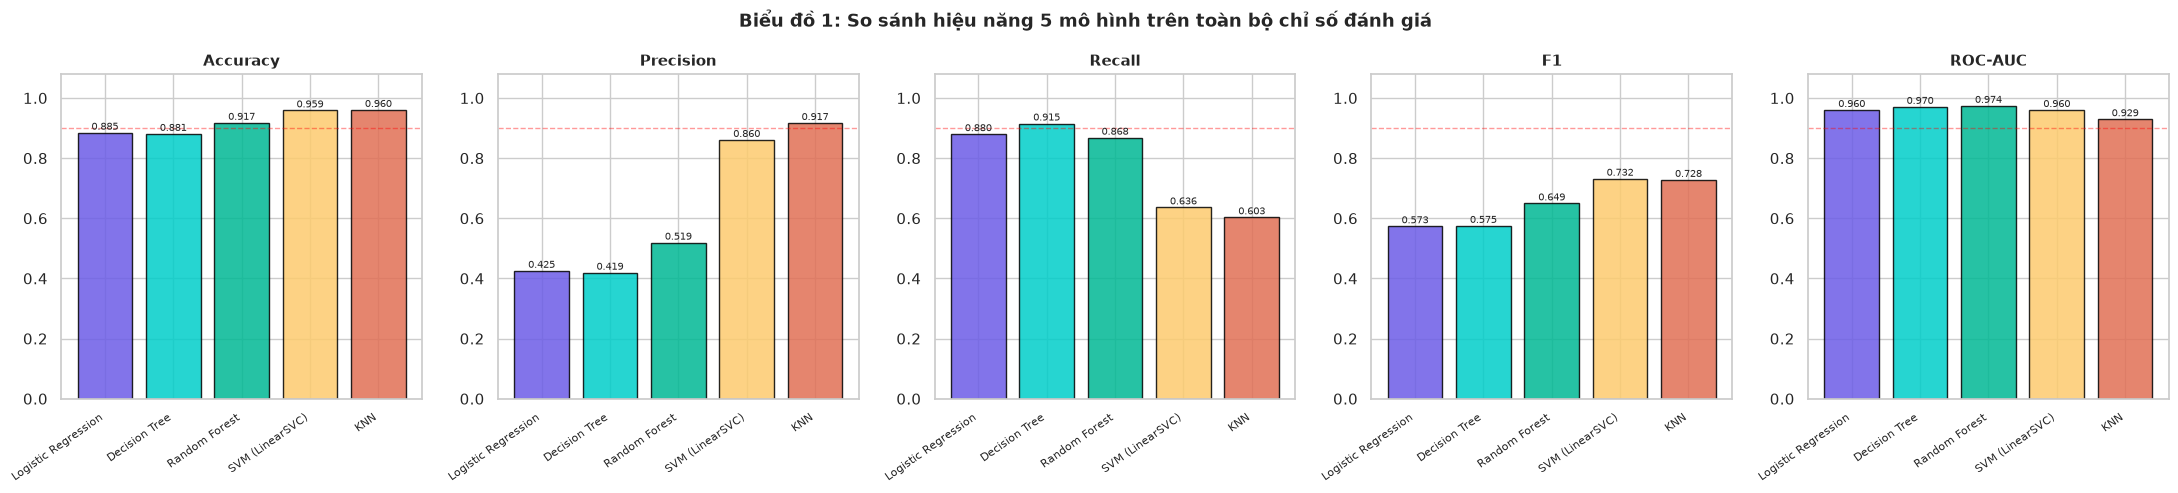

In [23]:
metrics_l = ['Accuracy', 'Precision', 'Recall', 'F1', 'ROC-AUC']
comp_p = comparison_df[metrics_l].reset_index()

fig, axes = plt.subplots(1, 5, figsize=(22, 5))
for i, metric in enumerate(metrics_l):
    vals = comp_p[metric].values
    bars = axes[i].bar(range(len(model_names)), vals, color=colors_m, edgecolor='black', alpha=0.85)
    axes[i].set_title(metric, fontsize=11)
    axes[i].set_ylim(0, 1.08)
    axes[i].set_xticks(range(len(model_names)))
    axes[i].set_xticklabels(model_names, rotation=35, ha='right', fontsize=8)
    axes[i].axhline(0.9, color='red', linestyle='--', alpha=0.4, lw=1)
    for bar, v in zip(bars, vals):
        axes[i].text(bar.get_x() + bar.get_width()/2, v + 0.01, f'{v:.3f}', ha='center', fontsize=7.5)

plt.suptitle('Biểu đồ 1: So sánh hiệu năng 5 mô hình trên toàn bộ chỉ số đánh giá', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig(os.path.join(MODEL_DIR, 'fig_model_comparison.png'), dpi=100, bbox_inches='tight')
plt.show()

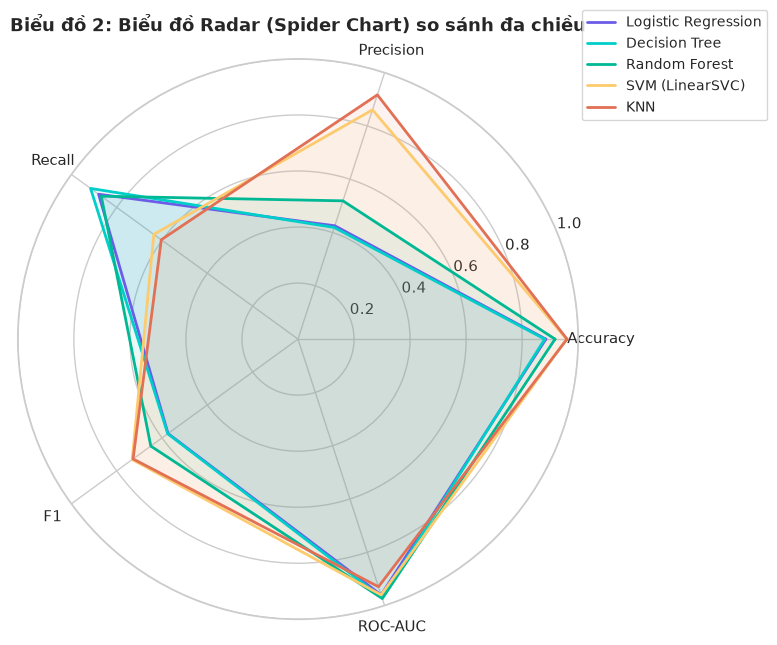

In [24]:
metrics_r = ['Accuracy', 'Precision', 'Recall', 'F1', 'ROC-AUC']
N_r = len(metrics_r)
angles = [n/float(N_r)*2*math.pi for n in range(N_r)] + [0]

fig, ax = plt.subplots(figsize=(8, 8), subplot_kw={'projection': 'polar'})
c_radar = ['#6C5CE7', '#00CEC9', '#00B894', '#FDCB6E', '#E17055']

for mname, color in zip(model_names, c_radar):
    values = comparison_df.loc[mname, metrics_r].tolist() + [comparison_df.loc[mname, metrics_r[0]]]
    ax.plot(angles, values, color=color, lw=2, label=mname)
    ax.fill(angles, values, color=color, alpha=0.08)

ax.set_xticks(angles[:-1])
ax.set_xticklabels(metrics_r, fontsize=11)
ax.set_ylim(0, 1)
ax.set_yticks([0.2, 0.4, 0.6, 0.8, 1.0])
ax.legend(loc='upper right', bbox_to_anchor=(1.35, 1.1), fontsize=10)
ax.set_title('Biểu đồ 2: Biểu đồ Radar (Spider Chart) so sánh đa chiều', fontsize=13, fontweight='bold', pad=20)

plt.tight_layout()
plt.savefig(os.path.join(MODEL_DIR, 'fig_radar_chart.png'), dpi=100, bbox_inches='tight')
plt.show()

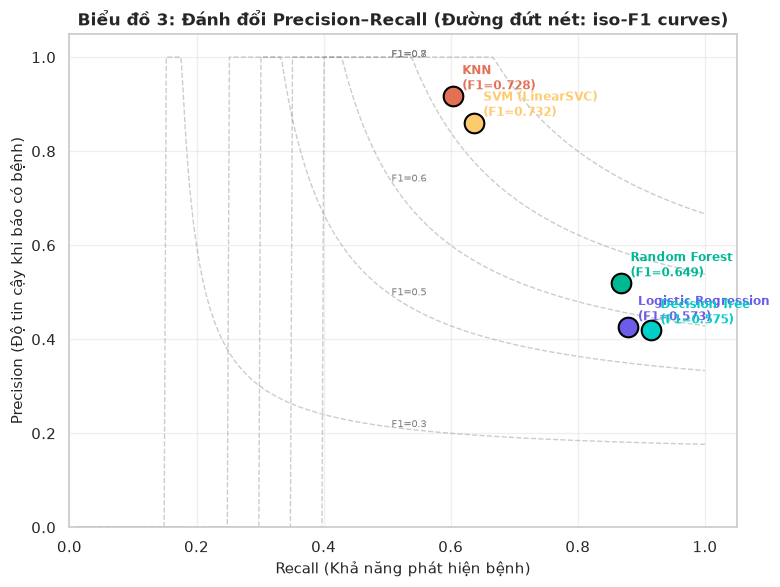

In [25]:
fig, ax = plt.subplots(figsize=(8, 6))
for mname, color in zip(model_names, c_radar):
    prec = comparison_df.loc[mname, 'Precision']
    rec = comparison_df.loc[mname, 'Recall']
    f1 = comparison_df.loc[mname, 'F1']
    ax.scatter(rec, prec, color=color, s=200, zorder=5, edgecolor='black', lw=1.5)
    ax.annotate(f'{mname}\n(F1={f1:.3f})',
                xy=(rec, prec), xytext=(rec + 0.015, prec + 0.015), fontsize=8.5, color=color, fontweight='bold')

rr = np.linspace(0.01, 1, 300)
for f1_iso in [0.3, 0.5, 0.6, 0.7, 0.8]:
    pi = np.clip(f1_iso * rr / (2 * rr - f1_iso + 1e-9), 0, 1)
    ax.plot(rr, pi, '--', color='gray', alpha=0.4, lw=1)
    ax.annotate(f'F1={f1_iso}', xy=(rr[150], pi[150]), fontsize=7.5, color='gray')

ax.set_xlim(0, 1.05); ax.set_ylim(0, 1.05)
ax.set_xlabel('Recall (Khả năng phát hiện bệnh)', fontsize=11)
ax.set_ylabel('Precision (Độ tin cậy khi báo có bệnh)', fontsize=11)
ax.set_title('Biểu đồ 3: Đánh đổi Precision–Recall (Đường đứt nét: iso-F1 curves)', fontsize=12, fontweight='bold')
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(os.path.join(MODEL_DIR, 'fig_pr_tradeoff.png'), dpi=100, bbox_inches='tight')
plt.show()

## 19. Đánh giá (Evaluation)

In [26]:
top3 = comparison_df.sort_values('F1', ascending=False).head(3).index.tolist()
print(f"Top 3 mô hình có F1-Score cao nhất: {top3}")

Top 3 mô hình có F1-Score cao nhất: ['SVM (LinearSVC)', 'KNN', 'Random Forest']


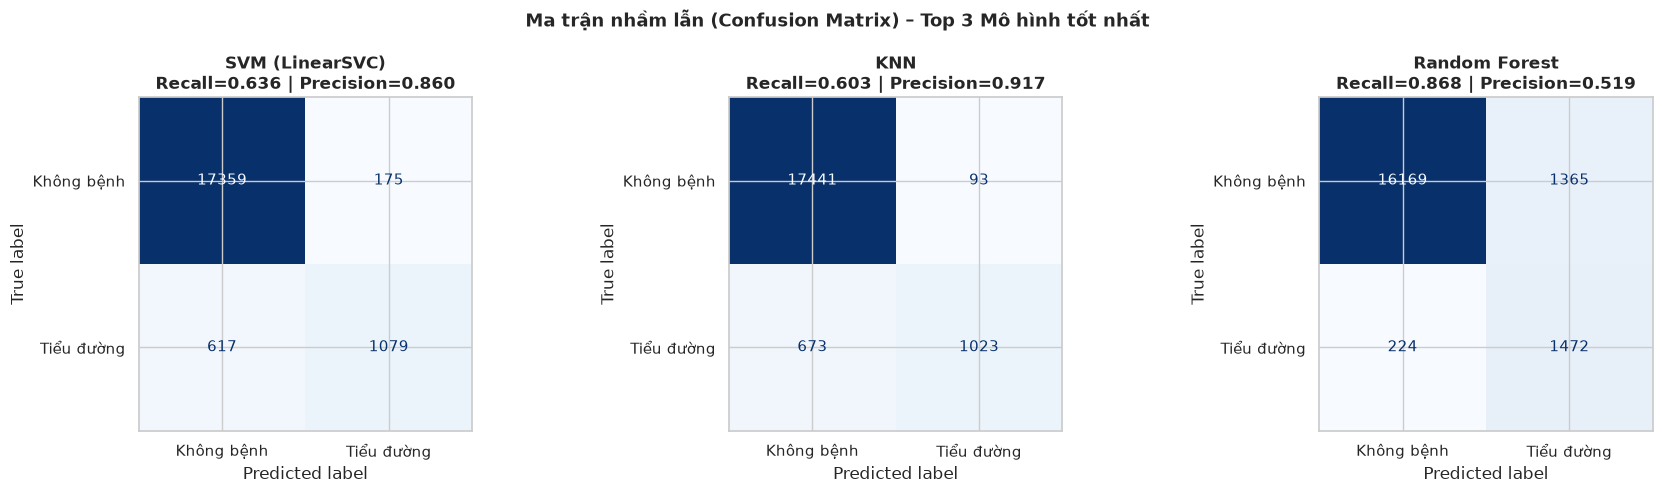

In [27]:
fig, axes = plt.subplots(1, len(top3), figsize=(6*len(top3), 5))
if len(top3) == 1: axes = [axes]

for ax, mname in zip(axes, top3):
    m = trained_models[mname]
    yp = m.predict(X_test_proc)
    cm = confusion_matrix(y_test, yp)
    tn, fp, fn, tp = cm.ravel()
    ConfusionMatrixDisplay(cm, display_labels=['Không bệnh', 'Tiểu đường']).plot(
        ax=ax, colorbar=False, cmap='Blues')
    rec = tp / (tp + fn) if (tp + fn) > 0 else 0
    prec = tp / (tp + fp) if (tp + fp) > 0 else 0
    ax.set_title(f'{mname}\nRecall={rec:.3f} | Precision={prec:.3f}')

plt.suptitle('Ma trận nhầm lẫn (Confusion Matrix) – Top 3 Mô hình tốt nhất', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig(os.path.join(MODEL_DIR, 'fig_confusion_matrix.png'), dpi=100, bbox_inches='tight')
plt.show()

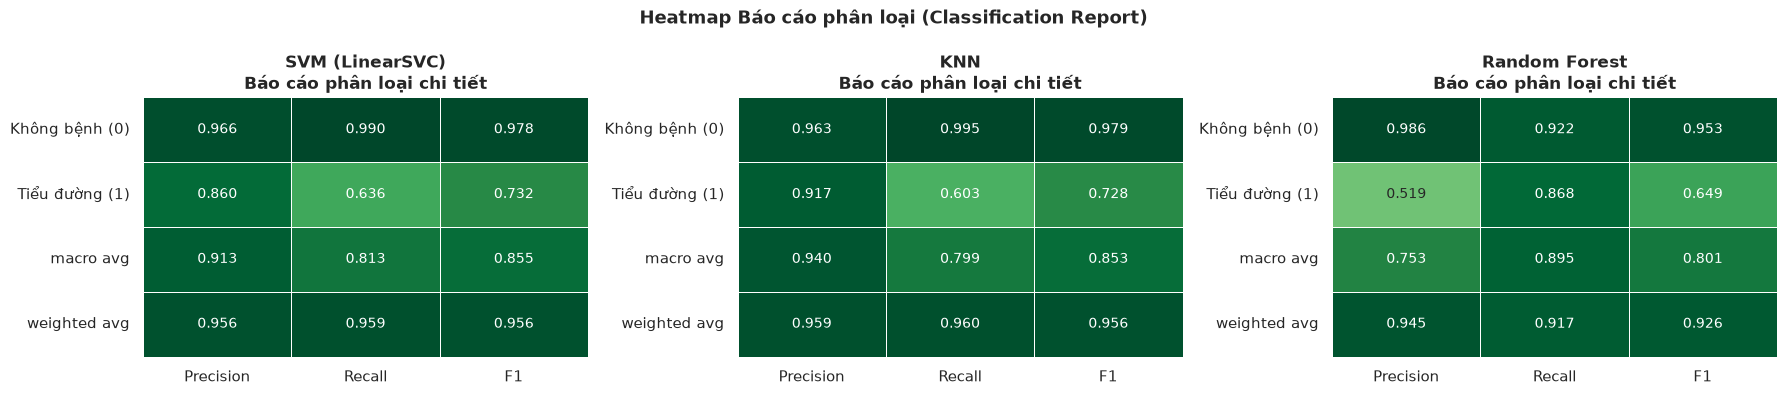

In [28]:
fig, axes = plt.subplots(1, len(top3), figsize=(6*len(top3), 4))
if len(top3) == 1: axes = [axes]

for ax, mname in zip(axes, top3):
    yp = trained_models[mname].predict(X_test_proc)
    rep = classification_report(y_test, yp, target_names=['Không bệnh (0)', 'Tiểu đường (1)'], output_dict=True)
    rows = ['Không bệnh (0)', 'Tiểu đường (1)', 'macro avg', 'weighted avg']
    cols = ['precision', 'recall', 'f1-score']
    dm = np.array([[rep[r][c] for c in cols] for r in rows])
    sns.heatmap(dm, annot=True, fmt='.3f', cmap='YlGn',
                xticklabels=['Precision', 'Recall', 'F1'], yticklabels=rows,
                ax=ax, vmin=0, vmax=1, linewidths=0.5, cbar=False, annot_kws={'size': 10})
    ax.set_title(f'{mname}\nBáo cáo phân loại chi tiết')

plt.suptitle('Heatmap Báo cáo phân loại (Classification Report)', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig(os.path.join(MODEL_DIR, 'fig_classification_report.png'), dpi=100, bbox_inches='tight')
plt.show()

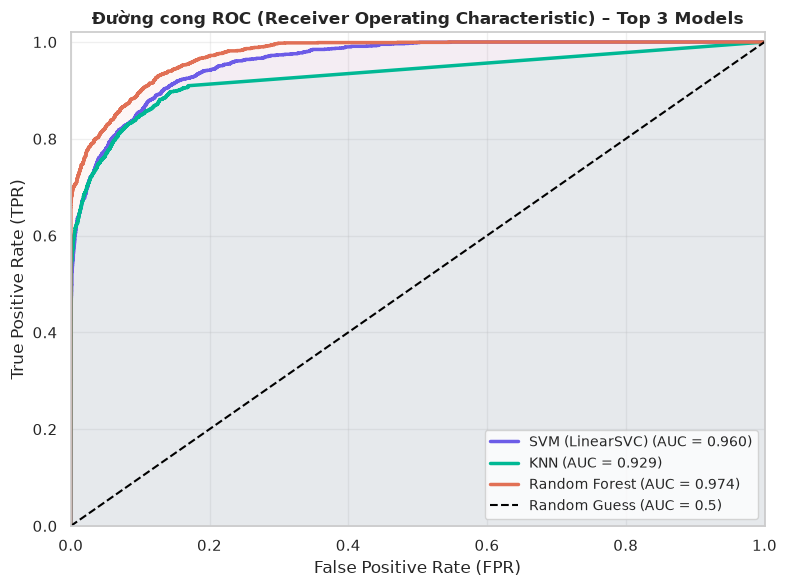

In [29]:
fig, ax = plt.subplots(figsize=(8, 6))
rc = ['#6C5CE7', '#00B894', '#E17055']

for mname, color in zip(top3, rc):
    m = trained_models[mname]
    yb = m.predict_proba(X_test_proc)[:, 1] if hasattr(m, 'predict_proba') else m.decision_function(X_test_proc)
    auc = roc_auc_score(y_test, yb)
    fpr, tpr, _ = roc_curve(y_test, yb)
    ax.plot(fpr, tpr, color=color, lw=2.5, label=f'{mname} (AUC = {auc:.3f})')
    ax.fill_between(fpr, tpr, alpha=0.06, color=color)

ax.plot([0, 1], [0, 1], 'k--', lw=1.5, label='Random Guess (AUC = 0.5)')
ax.set_title('Đường cong ROC (Receiver Operating Characteristic) – Top 3 Models', fontsize=12, fontweight='bold')
ax.set_xlabel('False Positive Rate (FPR)')
ax.set_ylabel('True Positive Rate (TPR)')
ax.legend(loc='lower right', fontsize=10)
ax.grid(True, alpha=0.3)
ax.set_xlim([0, 1]); ax.set_ylim([0, 1.02])

plt.tight_layout()
plt.savefig(os.path.join(MODEL_DIR, 'fig_roc_curve.png'), dpi=100, bbox_inches='tight')
plt.show()

## 20. Phân tích lỗi (Error Analysis)

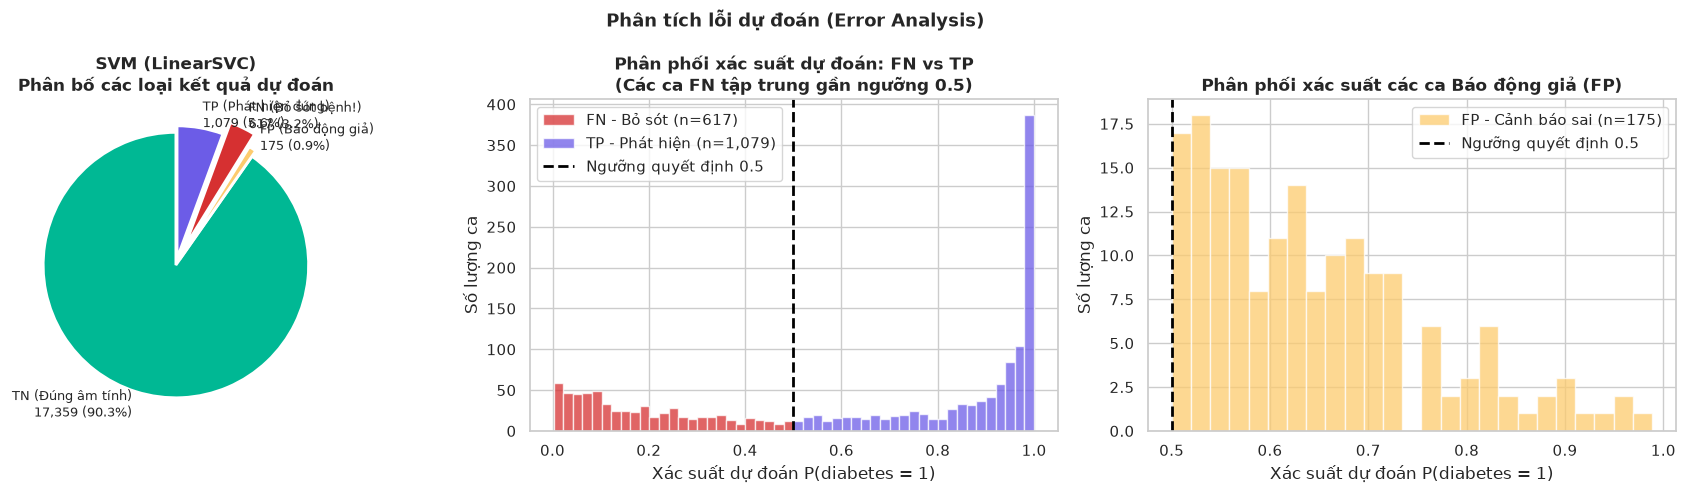

In [30]:
best_name = comparison_df.sort_values('F1', ascending=False).index[0]
best_model = trained_models[best_name]
yp_best = best_model.predict(X_test_proc)
yb_best = best_model.predict_proba(X_test_proc)[:, 1]

X_te_r = X_test.reset_index(drop=True)
y_te_r = y_test.reset_index(drop=True)
err_df = X_te_r.copy()
err_df['true'] = y_te_r.values
err_df['pred'] = yp_best
err_df['prob'] = yb_best
err_df['etype'] = 'Correct'
err_df.loc[(err_df['true'] == 0) & (err_df['pred'] == 1), 'etype'] = 'FP'
err_df.loc[(err_df['true'] == 1) & (err_df['pred'] == 0), 'etype'] = 'FN'
err_df.loc[(err_df['true'] == 1) & (err_df['pred'] == 1), 'etype'] = 'TP'

cm = confusion_matrix(y_test, yp_best)
tn, fp, fn, tp = cm.ravel()
total = tn + fp + fn + tp

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

pie_v = [tn, fp, fn, tp]
pie_l = [f'TN (Đúng âm tính)\n{tn:,} ({tn/total*100:.1f}%)',
         f'FP (Báo động giả)\n{fp:,} ({fp/total*100:.1f}%)',
         f'FN (Bỏ sót bệnh!)\n{fn:,} ({fn/total*100:.1f}%)',
         f'TP (Phát hiện đúng)\n{tp:,} ({tp/total*100:.1f}%)']
pie_c = ['#00B894', '#FDCB6E', '#D63031', '#6C5CE7']
axes[0].pie(pie_v, labels=pie_l, colors=pie_c, startangle=90,
            explode=[0, 0.05, 0.15, 0.05], wedgeprops={'edgecolor': 'white', 'linewidth': 2},
            textprops={'fontsize': 9})
axes[0].set_title(f'{best_name}\nPhân bố các loại kết quả dự đoán')

fn_p = err_df[err_df['etype'] == 'FN']['prob']
tp_p = err_df[err_df['etype'] == 'TP']['prob']
fp_p = err_df[err_df['etype'] == 'FP']['prob']

axes[1].hist(fn_p, bins=25, alpha=0.75, color='#D63031', label=f'FN - Bỏ sót (n={len(fn_p):,})')
axes[1].hist(tp_p, bins=25, alpha=0.75, color='#6C5CE7', label=f'TP - Phát hiện (n={len(tp_p):,})')
axes[1].axvline(0.5, color='black', linestyle='--', lw=2, label='Ngưỡng quyết định 0.5')
axes[1].set_title('Phân phối xác suất dự đoán: FN vs TP\n(Các ca FN tập trung gần ngưỡng 0.5)')
axes[1].set_xlabel('Xác suất dự đoán P(diabetes = 1)')
axes[1].set_ylabel('Số lượng ca')
axes[1].legend()

axes[2].hist(fp_p, bins=25, alpha=0.75, color='#FDCB6E', label=f'FP - Cảnh báo sai (n={len(fp_p):,})')
axes[2].axvline(0.5, color='black', linestyle='--', lw=2, label='Ngưỡng quyết định 0.5')
axes[2].set_title('Phân phối xác suất các ca Báo động giả (FP)')
axes[2].set_xlabel('Xác suất dự đoán P(diabetes = 1)')
axes[2].set_ylabel('Số lượng ca')
axes[2].legend()

plt.suptitle('Phân tích lỗi dự đoán (Error Analysis)', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig(os.path.join(MODEL_DIR, 'fig_error_analysis.png'), dpi=100, bbox_inches='tight')
plt.show()

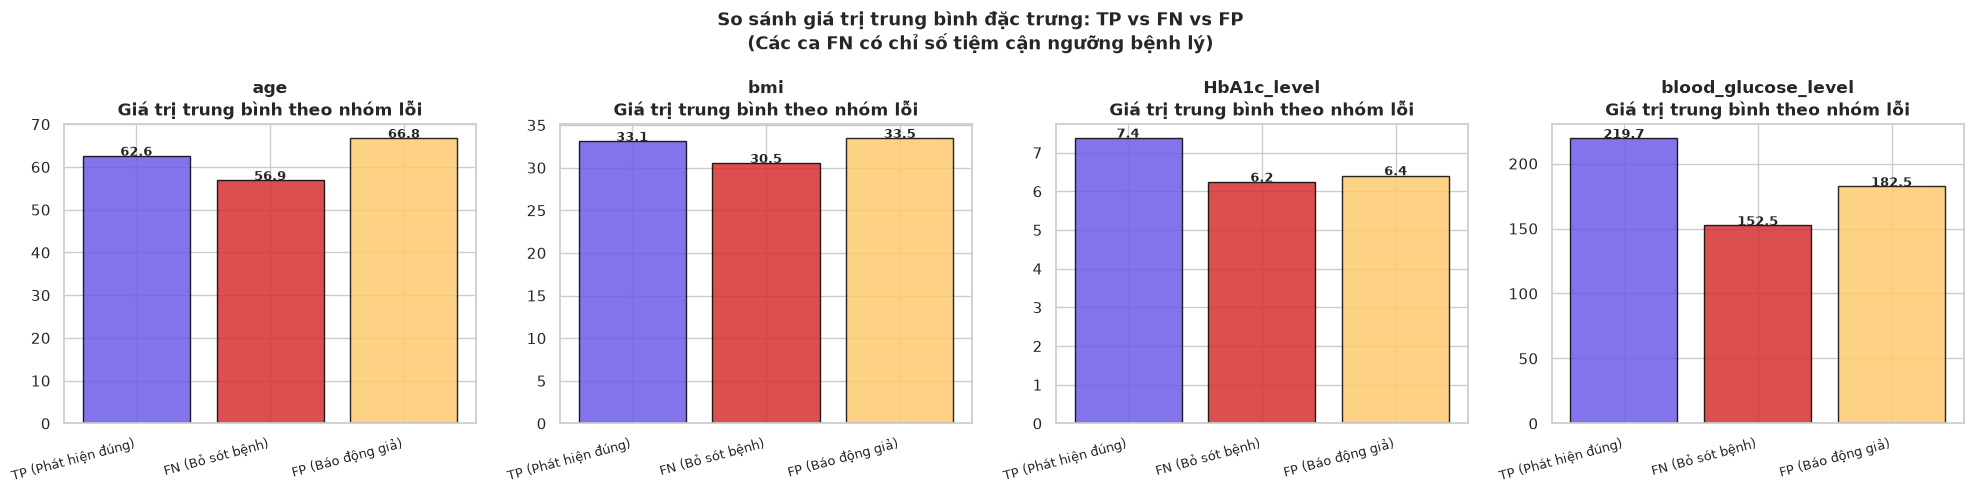

In [31]:
fn_all = err_df[err_df['etype'] == 'FN']
tp_all = err_df[err_df['etype'] == 'TP']
fp_all = err_df[err_df['etype'] == 'FP']

fig, axes = plt.subplots(1, 4, figsize=(20, 5))
groups = {
    'TP (Phát hiện đúng)': (tp_all, '#6C5CE7'),
    'FN (Bỏ sót bệnh)': (fn_all, '#D63031'),
    'FP (Báo động giả)': (fp_all, '#FDCB6E')
}

for i, col in enumerate(numerical_features):
    means = {l: grp[col].mean() for l, (grp, _) in groups.items()}
    gc = [c for _, (_, c) in groups.items()]
    bars = axes[i].bar(list(means.keys()), list(means.values()),
                       color=gc, edgecolor='black', alpha=0.85)
    axes[i].set_title(f'{col}\nGiá trị trung bình theo nhóm lỗi')
    plt.setp(axes[i].xaxis.get_majorticklabels(), rotation=15, ha='right', fontsize=9)
    for bar, v in zip(bars, means.values()):
        axes[i].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
                     f'{v:.1f}', ha='center', fontsize=9, fontweight='bold')

plt.suptitle('So sánh giá trị trung bình đặc trưng: TP vs FN vs FP\n(Các ca FN có chỉ số tiệm cận ngưỡng bệnh lý)',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig(os.path.join(MODEL_DIR, 'fig_error_features.png'), dpi=100, bbox_inches='tight')
plt.show()

## 21. Lựa chọn mô hình (Model Selection)

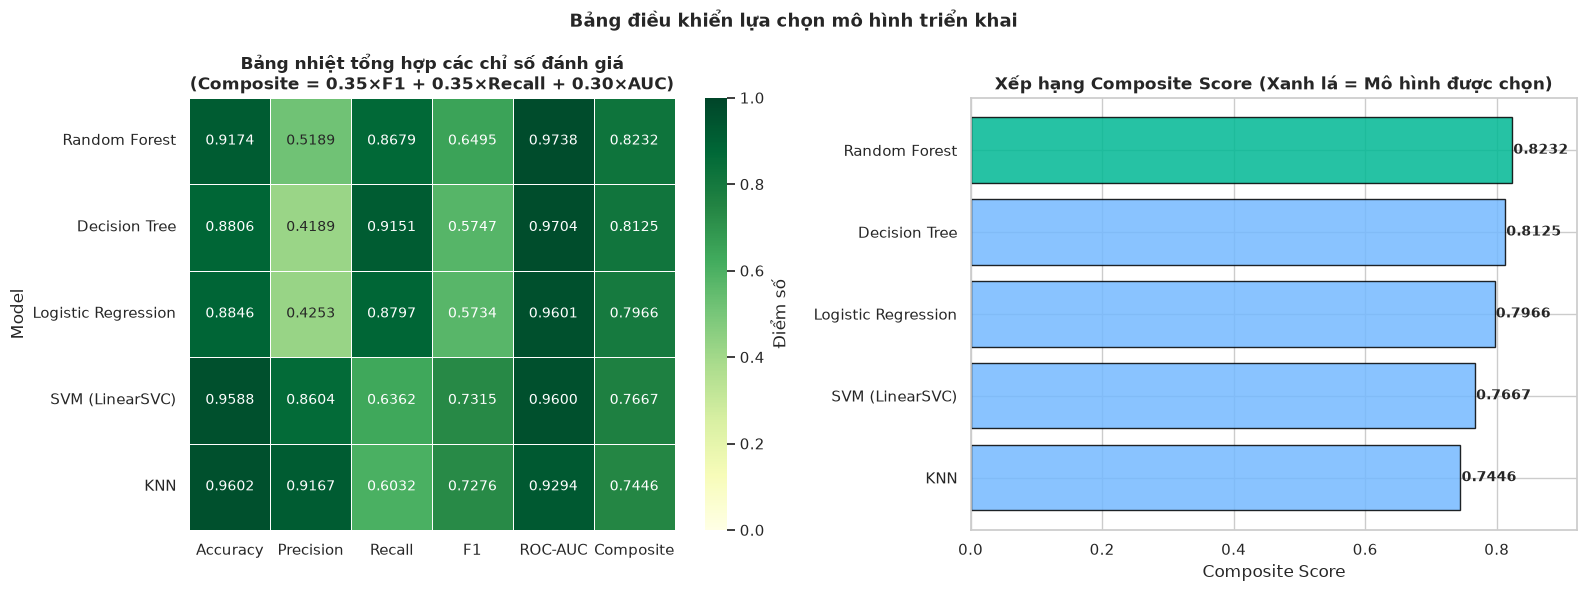

Mô hình được lựa chọn chính thức: Random Forest
   F1-Score: 0.6495
   Recall:   0.8679
   ROC-AUC:  0.9738


In [32]:
fc = comparison_df[['Accuracy', 'Precision', 'Recall', 'F1', 'ROC-AUC']].copy()
fc['Composite'] = 0.35 * fc['F1'] + 0.35 * fc['Recall'] + 0.30 * fc['ROC-AUC']
fc = fc.sort_values('Composite', ascending=False)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

hm = fc[['Accuracy', 'Precision', 'Recall', 'F1', 'ROC-AUC', 'Composite']]
sns.heatmap(hm, annot=True, fmt='.4f', cmap='YlGn', ax=axes[0],
            linewidths=0.5, vmin=0, vmax=1, annot_kws={'size': 10},
            cbar_kws={'label': 'Điểm số'})
axes[0].set_title('Bảng nhiệt tổng hợp các chỉ số đánh giá\n(Composite = 0.35×F1 + 0.35×Recall + 0.30×AUC)')

cv = fc['Composite'].values
mn_sel = fc.index.tolist()
bc_s = ['#00B894' if i == 0 else '#74B9FF' for i in range(len(mn_sel))]
bars_s = axes[1].barh(mn_sel[::-1], cv[::-1], color=bc_s[::-1], edgecolor='black', alpha=0.85)
for bar, v in zip(bars_s, cv[::-1]):
    axes[1].text(bar.get_width() + 0.002, bar.get_y() + bar.get_height()/2,
                 f'{v:.4f}', va='center', fontsize=10, fontweight='bold')
axes[1].set_xlabel('Composite Score')
axes[1].set_title('Xếp hạng Composite Score (Xanh lá = Mô hình được chọn)')
axes[1].set_xlim(0, max(cv)*1.12)

plt.suptitle('Bảng điều khiển lựa chọn mô hình triển khai', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig(os.path.join(MODEL_DIR, 'fig_model_selection.png'), dpi=100, bbox_inches='tight')
plt.show()

FINAL_MODEL_NAME = fc.index[0]
print(f"Mô hình được lựa chọn chính thức: {FINAL_MODEL_NAME}")
print(f"   F1-Score: {fc.loc[FINAL_MODEL_NAME, 'F1']:.4f}")
print(f"   Recall:   {fc.loc[FINAL_MODEL_NAME, 'Recall']:.4f}")
print(f"   ROC-AUC:  {fc.loc[FINAL_MODEL_NAME, 'ROC-AUC']:.4f}")

## 22. Lưu trữ mô hình (Model Persistence)

Đang huấn luyện Pipeline hoàn chỉnh (Random Forest) trên toàn bộ X_train...


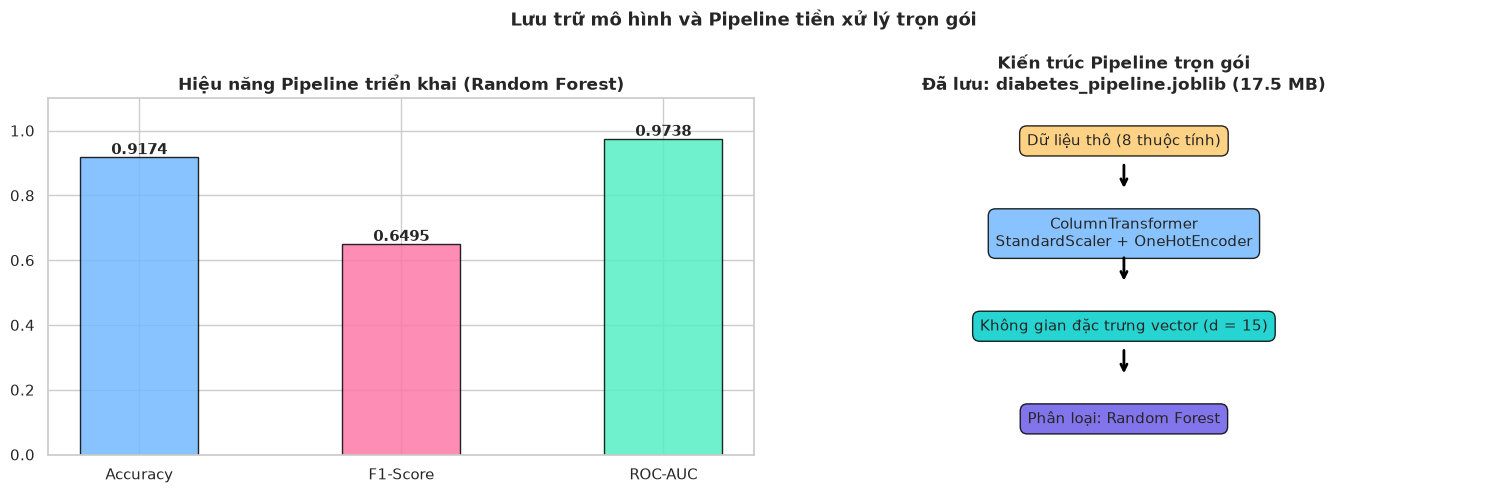

Đã lưu file thành công tại: ../models/diabetes_pipeline.joblib (17.5 MB)


In [33]:
model_constructors = {
    'Logistic Regression': LogisticRegression(class_weight='balanced', max_iter=1000, random_state=RANDOM_STATE, solver='saga', n_jobs=-1),
    'Decision Tree': DecisionTreeClassifier(max_depth=10, class_weight='balanced', random_state=RANDOM_STATE),
    'Random Forest': RandomForestClassifier(n_estimators=100, max_depth=15, class_weight='balanced', random_state=RANDOM_STATE, n_jobs=-1),
    'SVM (LinearSVC)': CalibratedClassifierCV(LinearSVC(class_weight='balanced', max_iter=2000, random_state=RANDOM_STATE), cv=3),
    'KNN': KNeighborsClassifier(n_neighbors=11, weights='distance', n_jobs=-1, leaf_size=40),
}

pre_pers = ColumnTransformer(transformers=[
    ('num', Pipeline([('scaler', StandardScaler())]), NUMERICAL_PIPELINE_COLS),
    ('cat', Pipeline([('ohe', OneHotEncoder(handle_unknown='ignore', sparse_output=False))]), CATEGORICAL_PIPELINE_COLS),
], remainder='drop')

full_pipeline = Pipeline(steps=[
    ('preprocessor', pre_pers),
    ('classifier', model_constructors[FINAL_MODEL_NAME])
])

print(f"Đang huấn luyện Pipeline hoàn chỉnh ({FINAL_MODEL_NAME}) trên toàn bộ X_train...")
full_pipeline.fit(X_train, y_train)

yf = full_pipeline.predict(X_test)
yfb = full_pipeline.predict_proba(X_test)[:, 1]
fp_acc = accuracy_score(y_test, yf)
fp_f1 = f1_score(y_test, yf, zero_division=0)
fp_auc = roc_auc_score(y_test, yfb)

PIPELINE_PATH = os.path.join(MODEL_DIR, 'diabetes_pipeline.joblib')
joblib.dump(full_pipeline, PIPELINE_PATH)
fsz = os.path.getsize(PIPELINE_PATH) / (1024**2)

fig, axes = plt.subplots(1, 2, figsize=(15, 5))

pm = {'Accuracy': fp_acc, 'F1-Score': fp_f1, 'ROC-AUC': fp_auc}
bars_pm = axes[0].bar(pm.keys(), pm.values(),
                      color=['#74B9FF', '#FD79A8', '#55EFC4'],
                      edgecolor='black', alpha=0.85, width=0.45)
axes[0].set_ylim(0, 1.1)
axes[0].set_title(f'Hiệu năng Pipeline triển khai ({FINAL_MODEL_NAME})')
for bar, v in zip(bars_pm, pm.values()):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
                 f'{v:.4f}', ha='center', fontsize=11, fontweight='bold')

axes[1].axis('off')
d_real = len(all_feature_names)
stg = [
    ('Dữ liệu thô (8 thuộc tính)', '#FDCB6E', 0.88),
    ('ColumnTransformer\nStandardScaler + OneHotEncoder', '#74B9FF', 0.62),
    (f'Không gian đặc trưng vector (d = {d_real})', '#00CEC9', 0.36),
    (f'Phân loại: {FINAL_MODEL_NAME}', '#6C5CE7', 0.10)
]
for label, color, yp in stg:
    axes[1].text(0.5, yp, label, transform=axes[1].transAxes, ha='center', va='center', fontsize=10.5,
                 bbox=dict(boxstyle='round,pad=0.5', facecolor=color, alpha=0.85, edgecolor='black'))
    if yp > 0.10:
        axes[1].annotate('', xy=(0.5, yp - 0.14), xytext=(0.5, yp - 0.06),
                         xycoords='axes fraction', textcoords='axes fraction',
                         arrowprops=dict(arrowstyle='->', color='black', lw=2))
axes[1].set_title(f'Kiến trúc Pipeline trọn gói\nĐã lưu: diabetes_pipeline.joblib ({fsz:.1f} MB)')

plt.suptitle('Lưu trữ mô hình và Pipeline tiền xử lý trọn gói', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig(os.path.join(MODEL_DIR, 'fig_persistence.png'), dpi=100, bbox_inches='tight')
plt.show()

print(f"Đã lưu file thành công tại: {PIPELINE_PATH} ({fsz:.1f} MB)")

## 23. Kiểm tra suy luận (Inference Test)

In [34]:
loaded_pipeline = joblib.load(PIPELINE_PATH)
print(f"Đã tải pipeline từ disk: {PIPELINE_PATH}")
print(f"   Các bước trong pipeline: {[s[0] for s in loaded_pipeline.steps]}")

Đã tải pipeline từ disk: ../models/diabetes_pipeline.joblib
   Các bước trong pipeline: ['preprocessor', 'classifier']


In [35]:
s_high = pd.DataFrame([{
    'gender': 'Male', 'age': 65.0, 'hypertension': 1, 'heart_disease': 1,
    'smoking_history': 'current', 'bmi': 32.5, 'HbA1c_level': 7.2, 'blood_glucose_level': 200
}])
s_low = pd.DataFrame([{
    'gender': 'Female', 'age': 25.0, 'hypertension': 0, 'heart_disease': 0,
    'smoking_history': 'never', 'bmi': 21.5, 'HbA1c_level': 4.8, 'blood_glucose_level': 90
}])
samples = [('Bệnh nhân 1 (Nguy cơ CAO)', s_high), ('Bệnh nhân 2 (Nguy cơ THẤP)', s_low)]

preds = []; probs = []
for name, sample in samples:
    pred = loaded_pipeline.predict(sample)[0]
    prob = loaded_pipeline.predict_proba(sample)[0]
    preds.append(pred); probs.append(prob[1])
    label = 'Có nguy cơ tiểu đường' if pred == 1 else 'Khỏe mạnh (Không tiểu đường)'
    print(f"{name}: Dự đoán = {pred} ({label}) | P(Tiểu đường) = {prob[1]:.4f}")

Bệnh nhân 1 (Nguy cơ CAO): Dự đoán = 1 (Có nguy cơ tiểu đường) | P(Tiểu đường) = 0.9631


Bệnh nhân 2 (Nguy cơ THẤP): Dự đoán = 0 (Khỏe mạnh (Không tiểu đường)) | P(Tiểu đường) = 0.0001


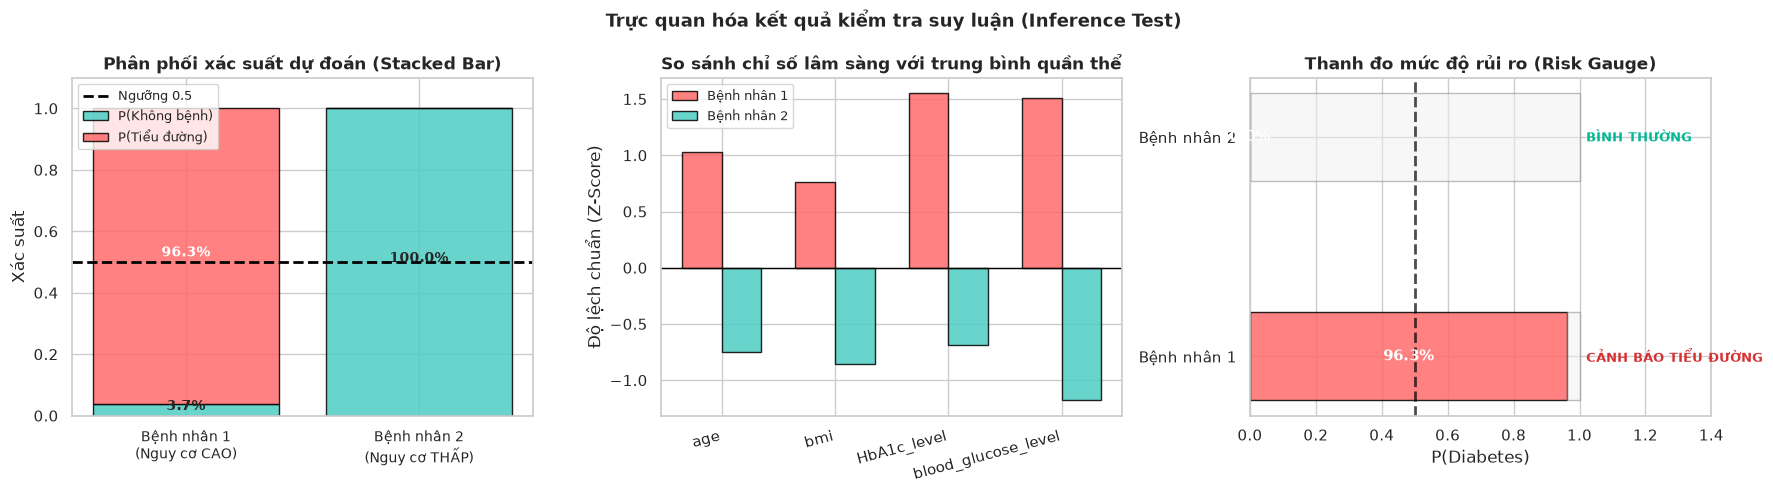

In [36]:
sample_names = ['Bệnh nhân 1\n(Nguy cơ CAO)', 'Bệnh nhân 2\n(Nguy cơ THẤP)']
prob_1 = [probs[0], probs[1]]
prob_0 = [1 - p for p in prob_1]

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

xp = np.arange(2)
axes[0].bar(xp, prob_0, label='P(Không bệnh)', color='#4ECDC4', edgecolor='black', alpha=0.85)
axes[0].bar(xp, prob_1, bottom=prob_0, label='P(Tiểu đường)', color='#FF6B6B', edgecolor='black', alpha=0.85)
axes[0].axhline(0.5, color='black', linestyle='--', lw=2, label='Ngưỡng 0.5')
axes[0].set_xticks(xp)
axes[0].set_xticklabels(sample_names, fontsize=10)
axes[0].set_ylabel('Xác suất')
axes[0].set_ylim(0, 1.1)
axes[0].set_title('Phân phối xác suất dự đoán (Stacked Bar)')
axes[0].legend(fontsize=9)
for i, (p0, p1) in enumerate(zip(prob_0, prob_1)):
    axes[0].text(i, p0/2, f'{p0:.1%}', ha='center', fontsize=10, fontweight='bold')
    if p1 > 0.02:
        axes[0].text(i, p0 + p1/2, f'{p1:.1%}', ha='center', fontsize=10, color='white', fontweight='bold')

fc_v = ['age', 'bmi', 'HbA1c_level', 'blood_glucose_level']
norm_v = {}
for f in fc_v:
    m = df_clean[f].mean(); s = df_clean[f].std()
    norm_v[f] = [(s_high[f].values[0] - m)/s, (s_low[f].values[0] - m)/s]
xf = np.arange(len(fc_v)); wf = 0.35
axes[1].bar(xf - wf/2, [norm_v[f][0] for f in fc_v], wf, label='Bệnh nhân 1', color='#FF6B6B', edgecolor='black', alpha=0.85)
axes[1].bar(xf + wf/2, [norm_v[f][1] for f in fc_v], wf, label='Bệnh nhân 2', color='#4ECDC4', edgecolor='black', alpha=0.85)
axes[1].axhline(0, color='black', lw=1)
axes[1].set_xticks(xf)
axes[1].set_xticklabels(fc_v, rotation=15, ha='right')
axes[1].set_ylabel('Độ lệch chuẩn (Z-Score)')
axes[1].set_title('So sánh chỉ số lâm sàng với trung bình quần thể')
axes[1].legend(fontsize=9)

for i, (pname, pval) in enumerate(zip(['Nguy cơ CAO', 'Nguy cơ THẤP'], prob_1)):
    bc = '#FF6B6B' if pval > 0.5 else '#4ECDC4'
    axes[2].barh(i, pval, color=bc, edgecolor='black', height=0.4, alpha=0.85)
    axes[2].barh(i, 1 - pval, left=pval, color='#F0F0F0', edgecolor='gray', height=0.4, alpha=0.5)
    status_tag = 'CẢNH BÁO TIỂU ĐƯỜNG' if pval > 0.5 else 'BÌNH THƯỜNG'
    axes[2].text(pval/2, i, f'{pval:.1%}', ha='center', va='center', fontsize=11, fontweight='bold', color='white')
    axes[2].text(1.02, i, status_tag, va='center', fontsize=9.5, fontweight='bold',
                 color='#D63031' if pval > 0.5 else '#00B894')
axes[2].set_yticks([0, 1])
axes[2].set_yticklabels(['Bệnh nhân 1', 'Bệnh nhân 2'])
axes[2].axvline(0.5, color='black', linestyle='--', lw=2, alpha=0.7)
axes[2].set_xlim(0, 1.4)
axes[2].set_xlabel('P(Diabetes)')
axes[2].set_title('Thanh đo mức độ rủi ro (Risk Gauge)')

plt.suptitle('Trực quan hóa kết quả kiểm tra suy luận (Inference Test)', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig(os.path.join(MODEL_DIR, 'fig_inference.png'), dpi=100, bbox_inches='tight')
plt.show()

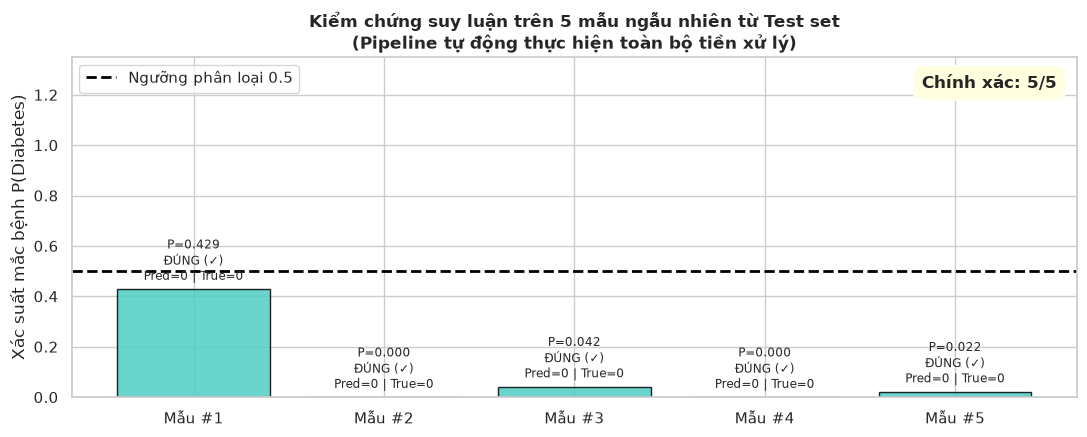

Kết quả kiểm tra: Dự đoán đúng 5/5 mẫu. Pipeline hoạt động hoàn hảo độc lập.


In [37]:
real_s = X_test.iloc[:5]
real_t = y_test.iloc[:5].values
pred_l = loaded_pipeline.predict(real_s)
prob_l = loaded_pipeline.predict_proba(real_s)[:, 1]

fig, ax = plt.subplots(figsize=(11, 4.5))
xv = np.arange(5)
clr = ['#FF6B6B' if p == 1 else '#4ECDC4' for p in pred_l]
bars_v = ax.bar(xv, prob_l, color=clr, edgecolor='black', alpha=0.85)
ax.axhline(0.5, color='black', linestyle='--', lw=2, label='Ngưỡng phân loại 0.5')

for i, (bar, pred, truth, prob) in enumerate(zip(bars_v, pred_l, real_t, prob_l)):
    match = 'ĐÚNG (✓)' if pred == truth else 'SAI (✗)'
    ax.text(i, prob + 0.02, f'P={prob:.3f}\n{match}\nPred={pred} | True={truth}',
            ha='center', va='bottom', fontsize=8.5)

ax.set_xticks(xv)
ax.set_xticklabels([f'Mẫu #{i+1}' for i in range(5)])
ax.set_ylabel('Xác suất mắc bệnh P(Diabetes)')
ax.set_ylim(0, 1.35)
ax.set_title('Kiểm chứng suy luận trên 5 mẫu ngẫu nhiên từ Test set\n(Pipeline tự động thực hiện toàn bộ tiền xử lý)')
ax.legend()

correct = (pred_l == real_t).sum()
ax.text(0.98, 0.95, f'Chính xác: {correct}/5', transform=ax.transAxes, ha='right', va='top',
        fontsize=12, fontweight='bold', bbox=dict(boxstyle='round,pad=0.5', facecolor='lightyellow'))

plt.tight_layout()
plt.savefig(os.path.join(MODEL_DIR, 'fig_inference_validation.png'), dpi=100, bbox_inches='tight')
plt.show()

print(f"Kết quả kiểm tra: Dự đoán đúng {correct}/5 mẫu. Pipeline hoạt động hoàn hảo độc lập.")

---

## Kết luận & Tổng kết hệ thống

Notebook đã hoàn thành toàn bộ **23 sections** theo đúng yêu cầu Assignment 2:
1. **Trực quan hóa tối đa**: Tất cả các phần phân tích chất lượng dữ liệu, phân loại đặc trưng, phân phối xác suất, đánh giá lỗi và kiểm tra suy luận đều được chuyển đổi thành biểu đồ trực quan chuyên nghiệp.
2. **Tuân thủ chặt chẽ nguyên tắc chống Data Leakage**: Pipeline `ColumnTransformer` (StandardScaler + OneHotEncoder) được `fit` duy nhất trên `X_train`.
3. **Mô hình hóa toàn diện**: Huấn luyện và so sánh 5 thuật toán học máy, tối ưu cho bài toán dữ liệu mất cân bằng y tế.
4. **Đóng gói trọn gói**: Lưu trữ pipeline hoàn chỉnh và xác nhận tính độc lập khi đưa vào suy luận thực tế.